<a href="https://colab.research.google.com/github/zaranindita/stock-prediction-boosting/blob/main/new_code_fix_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


In [2]:
pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29482 sha256=60ef7277c5b2f434e70c2abceebdc86242f850718596c96c103e922fe7b50381
  Stored in directory: /root/.cache/pip/wheels/e3/3a/ee/4955a26c90a4b7deb6d725dc8ec7b8604a7aef44e43a2e8af7
Successfully built ta


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import ta
import shap
shap.initjs()
warnings.filterwarnings('ignore')

from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [14]:
import yfinance as yf
from tqdm import tqdm

tickers = [
    "AADI.JK","ADMR.JK","ADRO.JK","AKRA.JK","AMMN.JK",
    "AMRT.JK","ANTM.JK","ASII.JK","BBCA.JK","BBNI.JK",
    "BBRI.JK","BBTN.JK","BMRI.JK","BRPT.JK","BUMI.JK",
    "CPIN.JK","CUAN.JK","DEWA.JK","EMTK.JK","ESSA.JK",
    "EXCL.JK","GOTO.JK","HRTA.JK","ICBP.JK","INCO.JK",
    "INDF.JK","INKP.JK","ISAT.JK","ITMG.JK","JPFA.JK",
    "KLBF.JK","MAPI.JK","MBMA.JK","MDKA.JK","MEDC.JK",
    "PGAS.JK","PGEO.JK","PTBA.JK","SCMA.JK","SMGR.JK",
    "TLKM.JK","TOWR.JK","UNTR.JK","UNVR.JK","WIFI.JK"
]
start_date = "2024-12-01"
end_date = "2026-06-30"
all_data = []
for ticker in tqdm(tickers):
    try:

        df = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            auto_adjust=False,
            progress=False
        )

        if df.empty:
            print(f"{ticker} tidak memiliki data.")
            continue

        df.reset_index(inplace=True)

        # Jika kolom berbentuk MultiIndex
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Tambahkan kode saham
        df["Ticker"] = ticker.replace(".JK", "")

        all_data.append(df)

    except Exception as e:
        print(f"Gagal download {ticker}: {e}")
stock_data = pd.concat(all_data, ignore_index=True)
stock_data = stock_data.sort_values(
    by=["Ticker", "Date"]
).reset_index(drop=True)
stock_data = stock_data[
    [
        "Date",
        "Ticker",
        "Open",
        "High",
        "Low",
        "Close",
        "Adj Close",
        "Volume"
    ]
]
print("Jumlah Baris :", stock_data.shape[0])
print("Jumlah Kolom :", stock_data.shape[1])
print("Jumlah Saham :", stock_data["Ticker"].nunique())
stock_data.to_csv("Sahamlq45.csv", index=False)
print("\nDataset berhasil disimpan.")
print("LQ45_saham.csv")

100%|██████████| 45/45 [00:05<00:00,  8.03it/s]


Jumlah Baris : 16647
Jumlah Kolom : 8
Jumlah Saham : 45

Dataset berhasil disimpan.
LQ45_saham.csv


In [15]:
df = pd.read_csv("Sahamlq45.csv")
df.head()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2024-12-05,AADI,6650.0,6650.0,6650.0,6650.0,5880.733887,459400
1,2024-12-06,AADI,7975.0,7975.0,7975.0,7975.0,7052.458984,446600
2,2024-12-09,AADI,9550.0,9550.0,9550.0,9550.0,8445.264648,43658100
3,2024-12-10,AADI,10500.0,11375.0,9600.0,10275.0,9086.396484,228636600
4,2024-12-11,AADI,10275.0,10450.0,9575.0,9600.0,8489.480469,100219900


In [16]:
print("INFORMASI DATASET")
print(df.info())
print("\nJumlah Data :", df.shape)
print("\nJumlah Saham :", df["Ticker"].nunique())
print("\nNama Saham :")
print(sorted(df["Ticker"].unique()))

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16647 entries, 0 to 16646
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       16647 non-null  object 
 1   Ticker     16647 non-null  object 
 2   Open       16647 non-null  float64
 3   High       16647 non-null  float64
 4   Low        16647 non-null  float64
 5   Close      16647 non-null  float64
 6   Adj Close  16647 non-null  float64
 7   Volume     16647 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 1.0+ MB
None

Jumlah Data : (16647, 8)

Jumlah Saham : 45

Nama Saham :
['AADI', 'ADMR', 'ADRO', 'AKRA', 'AMMN', 'AMRT', 'ANTM', 'ASII', 'BBCA', 'BBNI', 'BBRI', 'BBTN', 'BMRI', 'BRPT', 'BUMI', 'CPIN', 'CUAN', 'DEWA', 'EMTK', 'ESSA', 'EXCL', 'GOTO', 'HRTA', 'ICBP', 'INCO', 'INDF', 'INKP', 'ISAT', 'ITMG', 'JPFA', 'KLBF', 'MAPI', 'MBMA', 'MDKA', 'MEDC', 'PGAS', 'PGEO', 'PTBA', 'SCMA', 'SMGR', 'TLKM', 'TOWR', 'UNTR', 'UN

In [12]:
print("\nMissing Value")
print(df.isnull().sum())
print("\nJumlah Data Duplikat :", df.duplicated().sum())


Missing Value
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Jumlah Data Duplikat : 0


In [13]:
df.groupby('Ticker').size().value_counts()
df.groupby('Ticker').size().sort_values().head()

,0
Ticker,
AADI,367
ADMR,367
ADRO,367
AKRA,367
AMMN,367


In [ ]:
print("\nStatistik Numerik")
print(df.describe())


Statistik Numerik
               Open          High           Low         Close     Adj Close  \
count  16647.000000  16647.000000  16647.000000  16647.000000  16647.000000   
mean    3795.671082   3855.361717   3727.399111   3788.075089   3577.902216   
std     5168.739246   5224.769116   5100.397230   5163.382850   4850.841382   
min       50.000000     50.000000     50.000000     50.000000     50.000000   
25%     1145.000000   1170.000000   1120.000000   1140.000000   1092.621887   
50%     2170.000000   2220.000000   2110.000000   2160.000000   2050.000000   
75%     4380.000000   4440.000000   4300.000000   4380.000000   4031.382568   
max    32625.000000  32825.000000  32200.000000  32500.000000  31381.632812   

             Volume  
count  1.664700e+04  
mean   2.435712e+08  
std    1.081362e+09  
min    0.000000e+00  
25%    1.354430e+07  
50%    3.535440e+07  
75%    1.044262e+08  
max    2.860058e+10  


In [ ]:
import pandas as pd
stock_data = stock_data.sort_values(["Ticker", "Date"]).reset_index(drop=True)
volatility_results = []

for ticker, group in stock_data.groupby("Ticker"):
    group = group.reset_index(drop=True)
    daily_return = group["Adj Close"].pct_change().dropna()

    volatility_results.append({
        "Ticker": ticker,
        "MeanPrice": group["Adj Close"].mean(),
        "StdDailyReturn(%)": daily_return.std() * 100,
        "CV_Price": group["Adj Close"].std() / group["Adj Close"].mean()
    })

volatility_df = pd.DataFrame(volatility_results).sort_values(
    "StdDailyReturn(%)", ascending=False
).reset_index(drop=True)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print(volatility_df.to_string(index=False))
print("\n--- Ringkasan ---")
print(f"Volatilitas tertinggi : {volatility_df.iloc[0]['Ticker']} "
      f"({volatility_df.iloc[0]['StdDailyReturn(%)']:.2f}%)")
print(f"Volatilitas terendah  : {volatility_df.iloc[-1]['Ticker']} "
      f"({volatility_df.iloc[-1]['StdDailyReturn(%)']:.2f}%)")
print(f"Rata-rata seluruh ticker : {volatility_df['StdDailyReturn(%)'].mean():.2f}%")

volatility_df.to_csv("volatility_per_ticker.xlxs", index=False)

Ticker  MeanPrice  StdDailyReturn(%)  CV_Price
  WIFI    2289.45               6.02      0.36
  CUAN    1382.30               6.02      0.41
  DEWA     306.74               5.52      0.59
  HRTA    1277.95               5.29      0.68
  BRPT    1972.48               5.28      0.51
  BUMI     172.28               5.16      0.49
  MBMA     518.83               4.87      0.28
  MDKA    2324.32               4.59      0.26
  AMMN    6838.68               4.52      0.22
  SCMA     231.95               4.52      0.34
  EMTK     801.56               4.46      0.39
  INCO    4203.75               4.23      0.31
  ADMR    1267.13               3.89      0.31
  ANTM    2668.08               3.65      0.31
  ESSA     617.03               3.50      0.13
  UNVR    1678.31               3.37      0.23
  INKP    7374.47               3.35      0.22
  AADI    7264.92               3.33      0.18
  ISAT    1950.99               3.32      0.13
  SMGR    2525.29               3.29      0.15
  PGEO    107

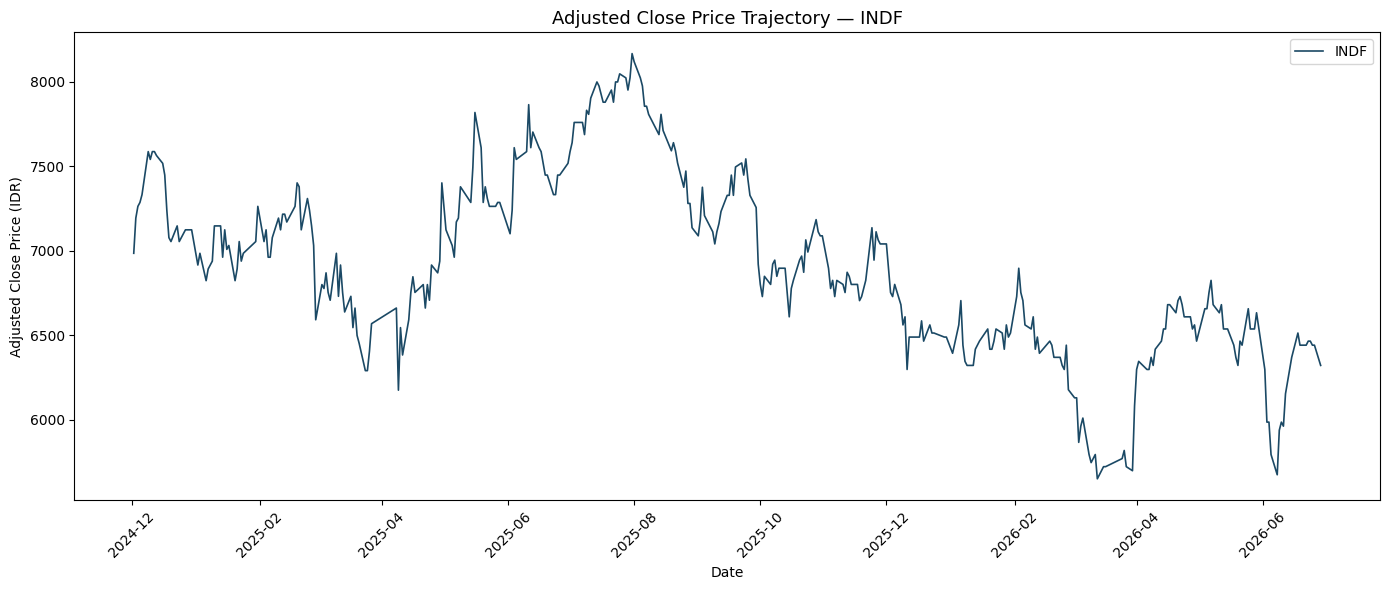

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pastikan Date sudah datetime
df["Date"] = pd.to_datetime(df["Date"])

sample_tickers = ["INDF"]

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in sample_tickers:
    subset = df[df["Ticker"] == ticker].sort_values("Date")
    ax.plot(subset["Date"], subset["Adj Close"], label=ticker, linewidth=1.2, color="#1B4965")

# Interval label tanggal per 2 bulan, biar granularity mirip grid sebelumnya
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

ax.set_title("Adjusted Close Price Trajectory — INDF", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close Price (IDR)")
ax.legend()
plt.tight_layout()
plt.savefig("figure1.png", dpi=300, bbox_inches="tight")
plt.show()

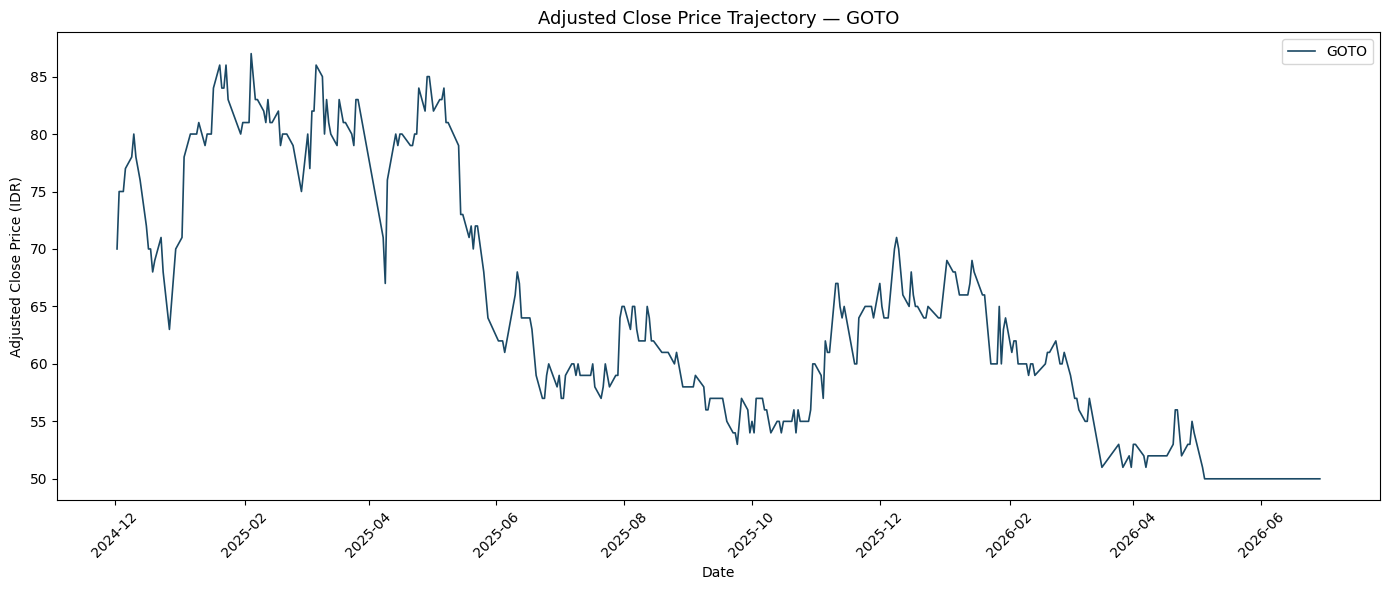

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pastikan Date sudah datetime
df["Date"] = pd.to_datetime(df["Date"])

sample_tickers = ["GOTO"]

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in sample_tickers:
    subset = df[df["Ticker"] == ticker].sort_values("Date")
    ax.plot(subset["Date"], subset["Adj Close"], label=ticker, linewidth=1.2, color="#1B4965")

# Interval label tanggal per 2 bulan, biar granularity mirip grid sebelumnya
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

ax.set_title("Adjusted Close Price Trajectory — GOTO", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close Price (IDR)")
ax.legend()
plt.tight_layout()
plt.savefig("figure1.png", dpi=300, bbox_inches="tight")
plt.show()

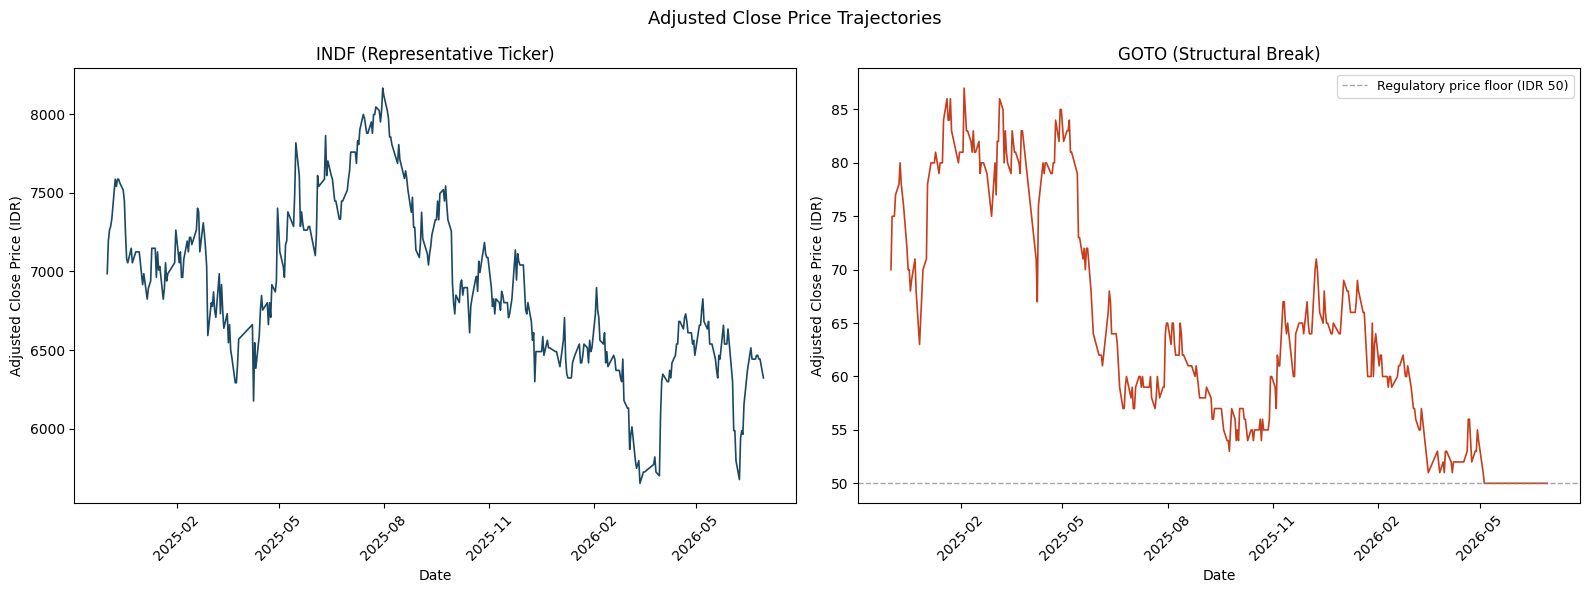

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
df["Date"] = pd.to_datetime(df["Date"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

subset_indf = df[df["Ticker"] == "INDF"].sort_values("Date")
axes[0].plot(subset_indf["Date"], subset_indf["Adj Close"],
             linewidth=1.2, color="#1B4965")
axes[0].set_title("INDF (Representative Ticker)", fontsize=12)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Adjusted Close Price (IDR)")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)


subset_goto = df[df["Ticker"] == "GOTO"].sort_values("Date")
axes[1].plot(subset_goto["Date"], subset_goto["Adj Close"],
             linewidth=1.2, color="#C73E1D")
axes[1].axhline(y=50, color="gray", linestyle="--", linewidth=1, alpha=0.7,
                 label="Regulatory price floor (IDR 50)")
axes[1].set_title("GOTO (Structural Break)", fontsize=12)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Adjusted Close Price (IDR)")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=9)

fig.suptitle("Adjusted Close Price Trajectories",
             fontsize=13)
plt.tight_layout()
plt.savefig("figure1.png", dpi=300, bbox_inches="tight")
plt.show()

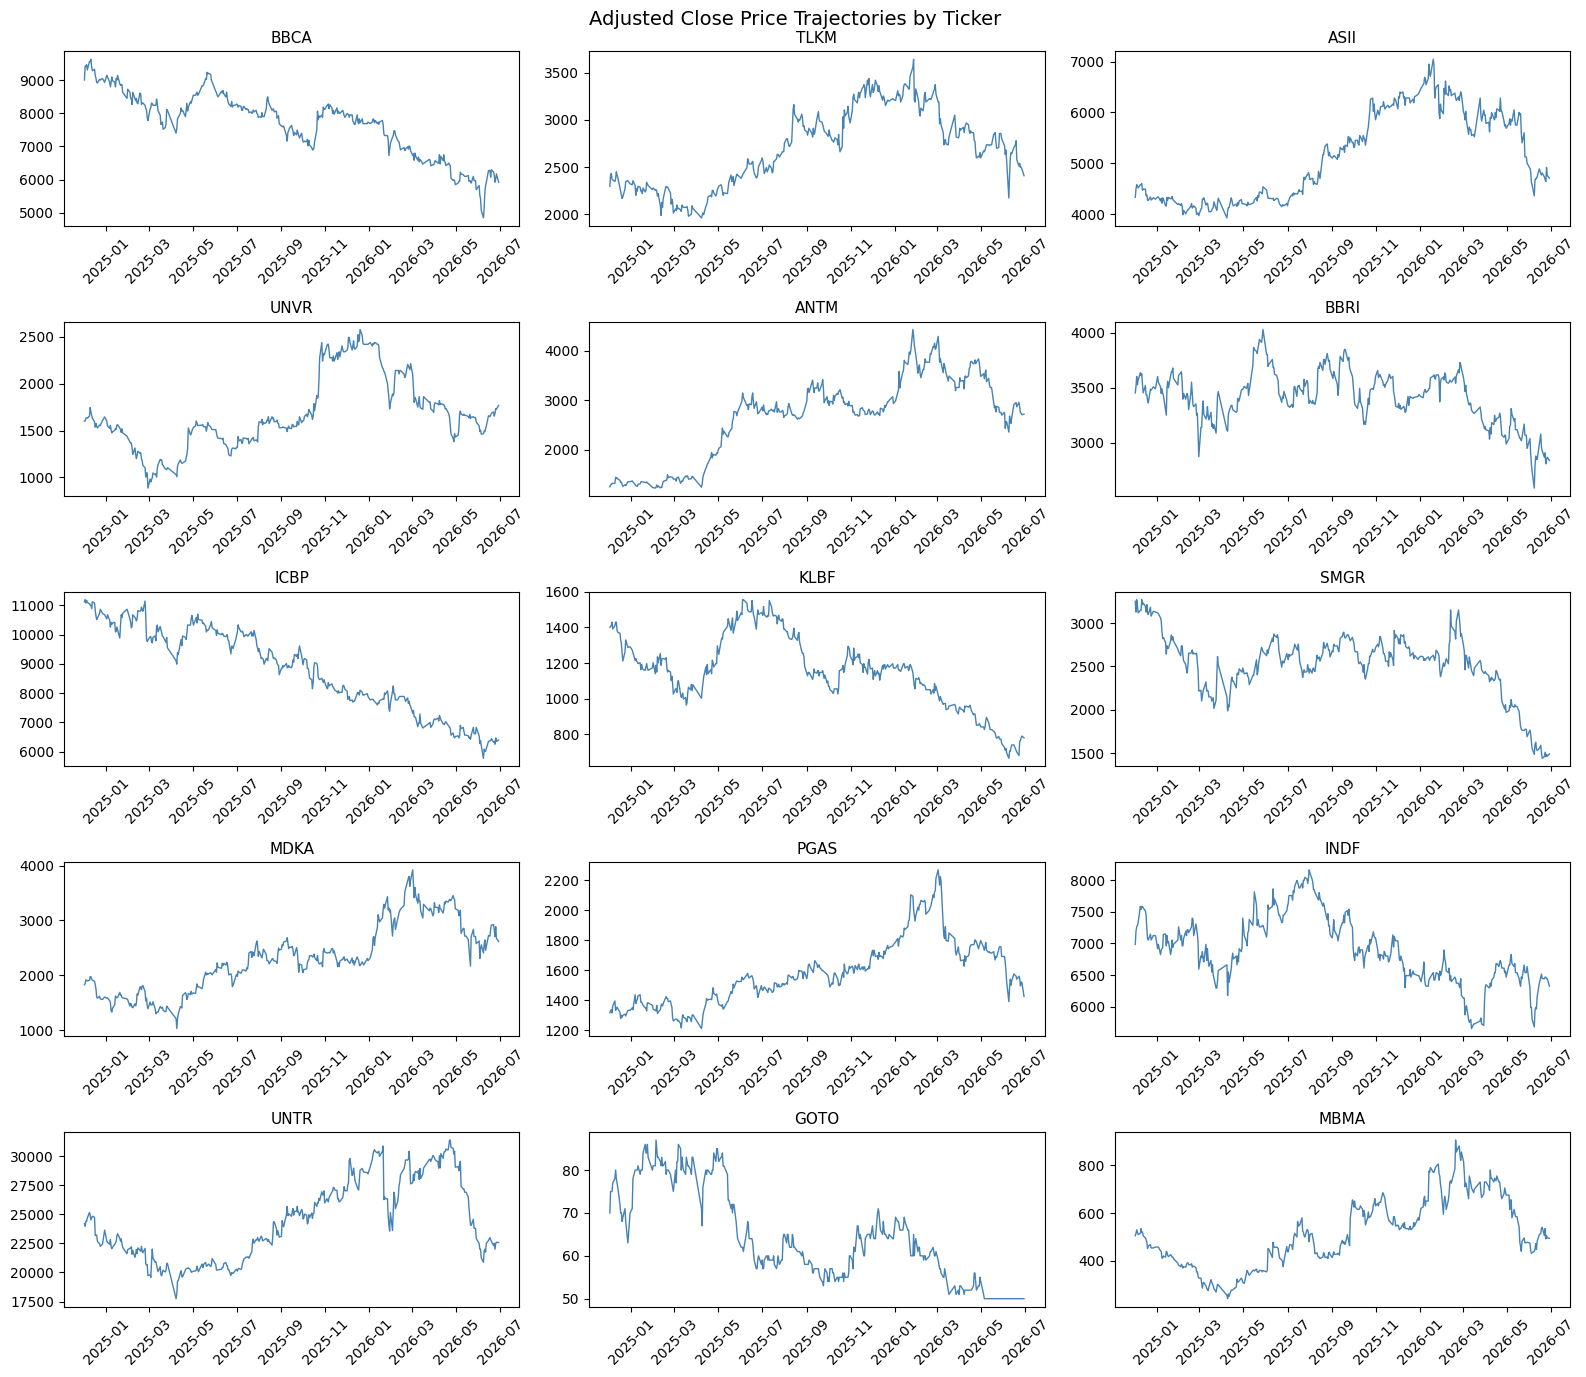

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pastikan Date udah datetime
df["Date"] = pd.to_datetime(df["Date"])

sample_tickers = ["BBCA", "TLKM", "ASII", "UNVR", "ANTM", "BBRI",
                   "ICBP", "KLBF", "SMGR", "MDKA", "PGAS", "INDF","UNTR","GOTO","MBMA"]

fig, axes = plt.subplots(5, 3, figsize=(16, 14))
axes = axes.flatten()

for i, ticker in enumerate(sample_tickers):
    subset = df[df["Ticker"] == ticker].sort_values("Date")
    axes[i].plot(subset["Date"], subset["Adj Close"], color="steelblue", linewidth=1)
    axes[i].set_title(ticker, fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Adjusted Close Price Trajectories by Ticker', fontsize=14)
plt.tight_layout()
plt.show()

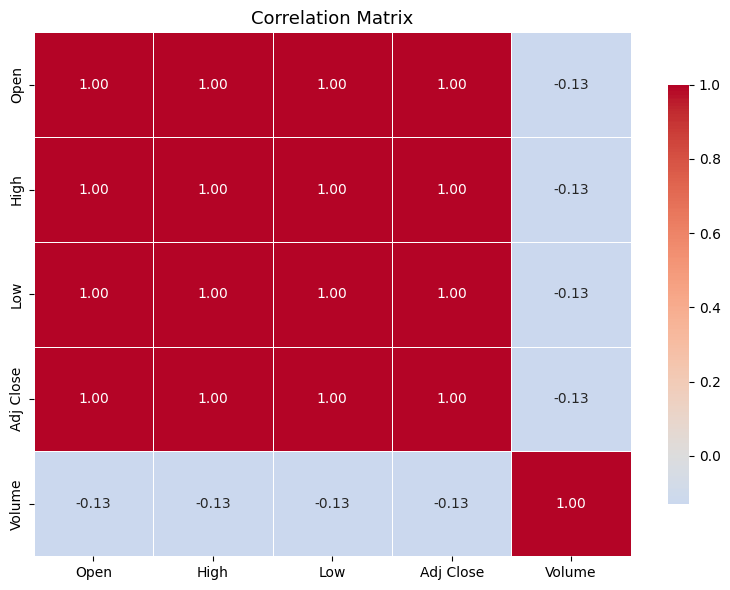

In [ ]:
corr_cols = ['Open', 'High', 'Low', 'Adj Close', 'Volume']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

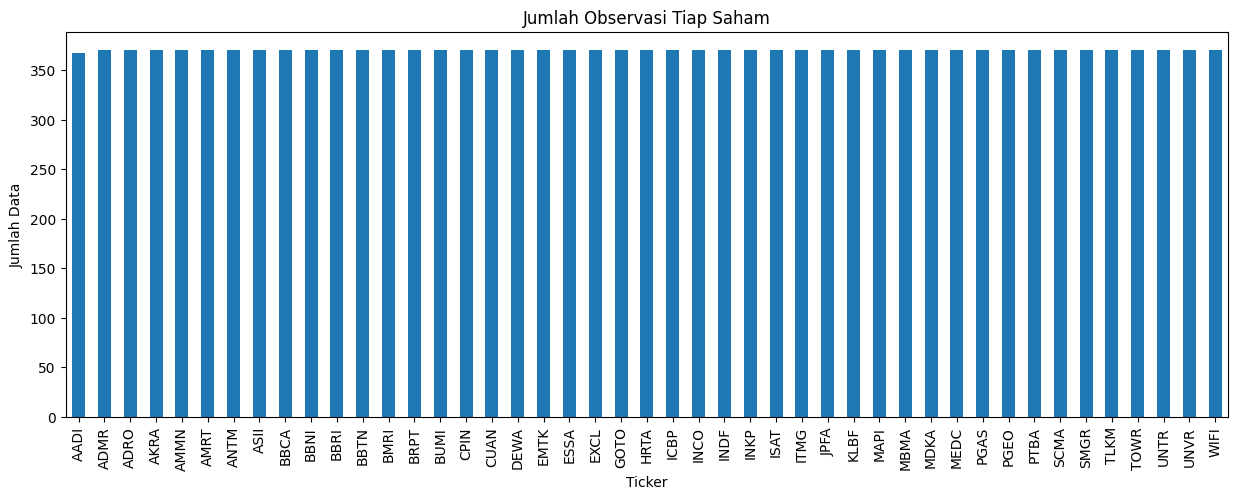

In [ ]:
hitung_saham = df["Ticker"].value_counts().sort_index()
plt.figure(figsize=(15,5))
hitung_saham.plot(kind="bar")
plt.title("Jumlah Observasi Tiap Saham")
plt.ylabel("Jumlah Data")
plt.show()

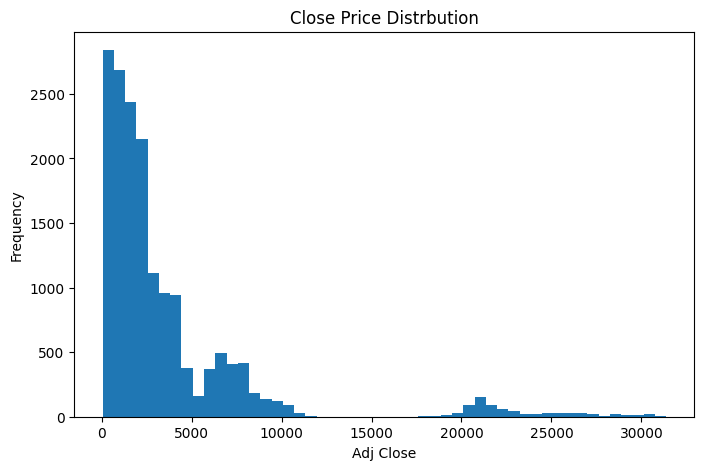

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Adj Close"], bins=50)
plt.title("Close Price Distrbution")
plt.xlabel("Adj Close")
plt.ylabel("Frequency")
plt.show()

In [ ]:
  from scipy.stats import skew
  print(skew(data["Adj Close"]))

3.140422397752172


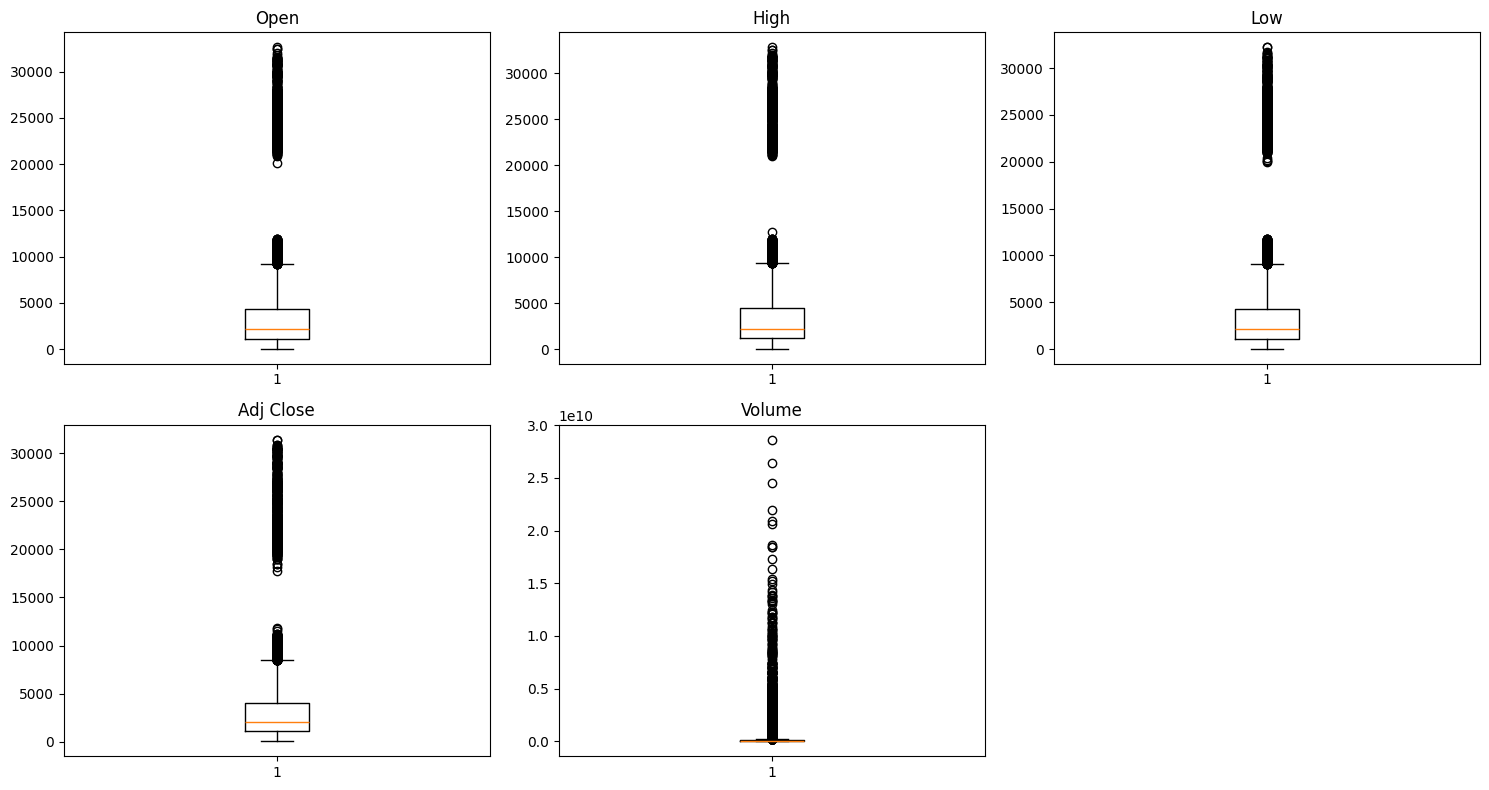

In [ ]:
import matplotlib.pyplot as plt
numerical_cols = ["Open", "High", "Low", "Adj Close", "Volume"]
plt.figure(figsize=(15,8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    plt.boxplot(df[col], vert=True)
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
def count_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers)

numerical_cols = ["Open","High","Low","Close","Adj Close","Volume"]
for col in numerical_cols:
    print(f"{col}: {count_outliers_iqr(df, col)} outlier")

Open: 1113 outlier
High: 1119 outlier
Low: 1116 outlier
Close: 1111 outlier
Adj Close: 1214 outlier
Volume: 1965 outlier


In [ ]:
def count_outliers_iqr_by_ticker(df, column):
    total = 0
    for _, g in df.groupby("Ticker"):
        q1, q3 = g[column].quantile([0.25, 0.75])
        iqr = q3 - q1
        total += ((g[column] < q1 - 1.5*iqr) | (g[column] > q3 + 1.5*iqr)).sum()
    return total

for col in numerical_cols:
    print(col, count_outliers_iqr_by_ticker(df, col))

Open 392
High 372
Low 417
Close 398
Adj Close 328
Volume 1115


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data = df.copy()

data = data.sort_values(["Ticker", "Date"]).reset_index(drop=True)

data["Ticker"] = le.fit_transform(data["Ticker"])


In [8]:
train_list = []
test_list = []

capping_summary = []

for ticker in data["Ticker"].unique():
    df_ticker = data[data["Ticker"] == ticker].sort_values("Date")
    split_idx = int(len(df_ticker) * 0.8)

    df_train = df_ticker.iloc[:split_idx].copy()
    df_test  = df_ticker.iloc[split_idx:].copy()

    lower = df_train["Volume"].quantile(0.02)
    upper = df_train["Volume"].quantile(0.98)

    # simpan sebelum capping
    train_before = df_train["Volume"].copy()
    test_before  = df_test["Volume"].copy()

    # capping
    df_train["Volume"] = df_train["Volume"].clip(lower, upper)
    df_test["Volume"]  = df_test["Volume"].clip(lower, upper)

    # hitung jumlah data yang berubah
    train_changed = (train_before != df_train["Volume"]).sum()
    test_changed  = (test_before != df_test["Volume"]).sum()

    capping_summary.append({
        "Ticker": le.inverse_transform([ticker])[0],
        "Lower": lower,
        "Upper": upper,
        "Train Changed": train_changed,
        "Test Changed": test_changed
    })

    train_list.append(df_train)
    test_list.append(df_test)

train_data = pd.concat(train_list).reset_index(drop=True)
test_data = pd.concat(test_list).reset_index(drop=True)

summary_df = pd.DataFrame(capping_summary)
summary_df.to_excel("capping_summary.xlsx", index=False)

print(summary_df)



   Ticker        Lower         Upper  Train Changed  Test Changed
0    AADI    4195132.0  6.501436e+07             12             5
1    ADMR    8888310.0  2.346183e+08             12             4
2    ADRO   25843760.0  4.667680e+08             12            11
3    AKRA    6415140.0  7.523088e+07             12             8
4    AMMN    9802120.0  1.048881e+08             12            25
5    AMRT   10262050.0  1.284343e+08             12            12
6    ANTM   23480450.0  5.151229e+08             12             4
7    ASII   15893560.0  1.284791e+08             12            10
8    BBCA   41568240.0  4.541671e+08             12            13
9    BBNI   21433790.0  1.776939e+08             12             8
10   BBRI   87391190.0  5.495645e+08             12             9
11   BBTN    7953260.0  1.133766e+08             12            10
12   BMRI   55524670.0  5.144266e+08             12             4
13   BRPT   30065280.0  5.948163e+08             12            11
14   BUMI 

In [ ]:
   after = pd.concat([train_data, test_data])["Volume"]
   print(data["Volume"].quantile([0.98, 0.99, 1.0]))
   print(after.quantile([0.98, 0.99, 1.0]))

0.98    2.938823e+09
0.99    4.920679e+09
1.00    2.860058e+10
Name: Volume, dtype: float64
0.98    2.864758e+09
0.99    4.902967e+09
1.00    1.843360e+10
Name: Volume, dtype: float64


In [ ]:
print("Sebelum")
print(data["Volume"].quantile([0.98, 0.99, 1.00]))

print()

print("Sesudah")
print(train_data["Volume"].quantile([0.98, 0.99, 1.00]))

Sebelum
0.98    2.938823e+09
0.99    4.920679e+09
1.00    2.860058e+10
Name: Volume, dtype: float64

Sesudah
0.98    2.829865e+09
0.99    5.088966e+09
1.00    1.843360e+10
Name: Volume, dtype: float64


In [ ]:
print(summary_df[["Train Changed", "Test Changed"]].describe())
print(summary_df.loc[summary_df["Total Changed"].idxmax(), ["Ticker", "Train Changed", "Test Changed"]])

       Train Changed  Test Changed
count           45.0     45.000000
mean            12.0     10.155556
std              0.0      6.728351
min             12.0      4.000000
25%             12.0      6.000000
50%             12.0      8.000000
75%             12.0     11.000000
max             12.0     32.000000
Ticker           SCMA
Train Changed      12
Test Changed       32
Name: 38, dtype: object


In [ ]:
summary_df["Train N"] = [len(d) for d in train_list]
summary_df["Test N"]  = [len(d) for d in test_list]
summary_df["Train %"] = summary_df["Train Changed"] / summary_df["Train N"] * 100
summary_df["Test %"]  = summary_df["Test Changed"]  / summary_df["Test N"]  * 100
print(summary_df[["Train %", "Test %"]].describe())

         Train %     Test %
count  45.000000  45.000000
mean    4.054976  13.723724
std     0.006188   9.092366
min     4.054054   5.405405
25%     4.054054   8.108108
50%     4.054054  10.810811
75%     4.054054  14.864865
max     4.095563  43.243243


In [ ]:
res = []
for i, t in enumerate(data["Ticker"].unique()):
    d = data[data["Ticker"] == t].sort_values("Date")
    test_raw = d.iloc[int(len(d) * 0.8):]["Volume"]
    lo, up = summary_df.loc[i, ["Lower", "Upper"]]
    res.append({"Above": (test_raw > up).sum(), "Below": (test_raw < lo).sum()})
print(pd.DataFrame(res).sum())

Above    151
Below    306
dtype: int64


In [ ]:
summary_df["Total Changed"] = (
    summary_df["Train Changed"] +
    summary_df["Test Changed"]
)

print(summary_df["Total Changed"].describe())

count    45.000000
mean     22.155556
std       6.728351
min      16.000000
25%      18.000000
50%      20.000000
75%      23.000000
max      44.000000
Name: Total Changed, dtype: float64


In [ ]:
print("Sebelum")
print(data["Volume"].describe())

print()

print("Sesudah")
print(train_data["Volume"].describe())

Sebelum
count    1.664700e+04
mean     2.435712e+08
std      1.081362e+09
min      0.000000e+00
25%      1.354430e+07
50%      3.535440e+07
75%      1.044262e+08
max      2.860058e+10
Name: Volume, dtype: float64

Sesudah
count    1.331700e+04
mean     2.418938e+08
std      1.066739e+09
min      4.505200e+05
25%      1.412060e+07
50%      3.596480e+07
75%      1.026455e+08
max      1.843360e+10
Name: Volume, dtype: float64


In [9]:
import ta

def feature_engineering(data, label=""):

    data = data.sort_values(["Ticker","Date"]).copy()

    # LAG
    lag_columns = ["Open","High","Low","Adj Close","Volume"]

    for col in lag_columns:
        for lag in range(1,6):
            data[f"{col.replace(' ','_')}_lag{lag}"] = (
                data.groupby("Ticker")[col]
                .shift(lag)
            )


    # SMA
    for window in [5,15,20]:

        sma = (
            data.groupby("Ticker")["Adj Close"]
            .transform(lambda x: x.rolling(window).mean())
        )

        data[f"SMA_{window}"] = data["Adj Close"] / sma


    # EMA
    for window in [5,15,20]:

        ema = (
            data.groupby("Ticker")["Adj Close"]
            .transform(lambda x: x.ewm(span=window,adjust=False).mean())
        )

        data[f"EMA_{window}"] = data["Adj Close"] / ema


    # MACD
    def add_macd(group):

        ema12 = group["Adj Close"].ewm(span=12,adjust=False).mean()
        ema26 = group["Adj Close"].ewm(span=26,adjust=False).mean()

        macd = ema12 - ema26
        signal = macd.ewm(span=9,adjust=False).mean()

        # Normalisasi MACD menjadi rasio sesuai Persamaan (2.8):
        # r_MACD,t = (MACD_t - SIG_t) / (0.5 * (|MACD_t| + |SIG_t|))
        denominator = 0.5 * (macd.abs() + signal.abs())

        group["MACD"] = (macd - signal) / denominator

        return group

    data = data.groupby(
        "Ticker",
        group_keys=False
    ).apply(add_macd)



    # RSI
    def add_rsi(group):

        group["RSI"] = ta.momentum.RSIIndicator(
            close=group["Adj Close"],
            window=14
        ).rsi()

        return group

    data = data.groupby(
        "Ticker",
        group_keys=False
    ).apply(add_rsi)


    # STOCHASTIC
    def add_stochastic(group):

        adj_ratio = group["Adj Close"] / group["Close"]

        high_adj = group["High"] * adj_ratio
        low_adj = group["Low"] * adj_ratio

        stoch = ta.momentum.StochasticOscillator(
            high=high_adj,
            low=low_adj,
            close=group["Adj Close"],
            window=14,
            smooth_window=3
        )

        group["STOCH_K"] = stoch.stoch()
        group["STOCH_D"] = stoch.stoch_signal()

        return group

    data = data.groupby(
        "Ticker",
        group_keys=False
    ).apply(add_stochastic)


    # TARGET
    data["Target"] = (
        data.groupby("Ticker")["Adj Close"]
        .shift(-1)
    )

    print(f"Sebelum dropna - {label}:", data.shape)

    raw_by_label[label] = data.copy()

    data = data.dropna().reset_index(drop=True)

    print(f"Sesudah dropna - {label}:", data.shape)

    return data

In [10]:
raw_by_label = {}   # di luar fungsi, jalankan sekali


In [11]:
train_data = feature_engineering(train_data, label="Train")
test_data  = feature_engineering(test_data, label="Test")

print("Train :", train_data.shape)
print("Test  :", test_data.shape)

Sebelum dropna - Train: (13317, 44)
Sesudah dropna - Train: (12417, 44)
Sebelum dropna - Test: (3330, 44)
Sesudah dropna - Test: (2413, 44)
Train : (12417, 44)
Test  : (2413, 44)


In [12]:
features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "Adj_Close_lag1",
    "Adj_Close_lag2",
    "Adj_Close_lag3",
    "Adj_Close_lag4",
    "Adj_Close_lag5",
    "Open_lag1",
    "Open_lag2",
    "Open_lag3",
    "Open_lag4",
    "Open_lag5",
    "High_lag1",
    "High_lag2",
    "High_lag3",
    "High_lag4",
    "High_lag5",
    "Low_lag1",
    "Low_lag2",
    "Low_lag3",
    "Low_lag4",
    "Low_lag5",
    "Volume_lag1",
    "Volume_lag2",
    "Volume_lag3",
    "Volume_lag4",
    "Volume_lag5",
    "SMA_5",
    "SMA_15",
    "SMA_20",
    "EMA_5",
    "EMA_15",
    "EMA_20",
    "MACD",
    "RSI",
    "STOCH_K",
    "STOCH_D"
]

target = "Target"
if "Ticker" not in features:
    features.append("Ticker")

In [13]:
X_train = train_data[features]
y_train = train_data["Target"]

X_test = test_data[features]
y_test = test_data["Target"]

print(X_train.shape)
print(X_test.shape)

(12417, 40)
(2413, 40)


In [ ]:
import numpy as np

t = raw_by_label["Test"]
na_rows = t.drop(columns=["Date"]).isna().any(axis=1)
cnt = t[na_rows].groupby("Ticker").size()

print(cnt.describe())

# ticker yang kehilangan baris selain 20 (19 warm-up + 1 target)
odd = cnt[cnt != 20]
print(pd.DataFrame({"Ticker": le.inverse_transform(odd.index), "Rows dropped": odd.values}))

# kolom mana yang berisi NaN
print(t.isna().sum()[lambda s: s > 0])

# inf tidak dihapus oleh dropna, jadi cek terpisah
num = t.select_dtypes("number")
print(np.isinf(num).sum()[lambda s: s > 0])

count    45.000000
mean     20.377778
std       2.534210
min      20.000000
25%      20.000000
50%      20.000000
75%      20.000000
max      37.000000
dtype: float64
  Ticker  Rows dropped
0   GOTO            37
Open_lag1          45
Open_lag2          90
Open_lag3         135
Open_lag4         180
Open_lag5         225
High_lag1          45
High_lag2          90
High_lag3         135
High_lag4         180
High_lag5         225
Low_lag1           45
Low_lag2           90
Low_lag3          135
Low_lag4          180
Low_lag5          225
Adj_Close_lag1     45
Adj_Close_lag2     90
Adj_Close_lag3    135
Adj_Close_lag4    180
Adj_Close_lag5    225
Volume_lag1        45
Volume_lag2        90
Volume_lag3       135
Volume_lag4       180
Volume_lag5       225
SMA_5             180
SMA_15            630
SMA_20            855
MACD               46
RSI               585
STOCH_K           603
STOCH_D           693
Target             45
dtype: int64
Series([], dtype: int64)


In [16]:
# 1. Tanggal terakhir GOTO di test set (sebelum dropna)
print(x["Date"].max())

# 2. Baris NaN GOTO, urutkan by Date, lihat semua kolom yang NaN per baris
bad = x[x.drop(columns=["Date"]).isna().any(axis=1)].sort_values("Date")
print(bad[["Date"]])   # liat urutan tanggalnya, cocokkan sama yg 18 baris kemarin

# 3. Cek spesifik: baris mana yang NaN di kolom Target (bukan STOCH)
print(bad[bad["Target"].isna()][["Date", "STOCH_K", "Target"]])

# 4. Cek overlap: dari baris yang NaN, mana yang NaN HANYA di STOCH_K (semua kolom lain terisi)
only_stoch_nan = bad[bad.drop(columns=["Date", "STOCH_K"]).notna().all(axis=1) & bad["STOCH_K"].isna()]
print(len(only_stoch_nan))
print(only_stoch_nan[["Date"]])

2026-06-29
            Date
1554  2026-03-05
1555  2026-03-06
1556  2026-03-09
1557  2026-03-10
1558  2026-03-11
1559  2026-03-12
1560  2026-03-13
1561  2026-03-16
1562  2026-03-17
1563  2026-03-25
1564  2026-03-26
1565  2026-03-27
1566  2026-03-30
1567  2026-03-31
1568  2026-04-01
1569  2026-04-02
1570  2026-04-06
1571  2026-04-07
1572  2026-04-08
1610  2026-06-03
1611  2026-06-04
1612  2026-06-05
1613  2026-06-08
1614  2026-06-09
1615  2026-06-10
1616  2026-06-11
1617  2026-06-12
1618  2026-06-15
1619  2026-06-17
1620  2026-06-18
1621  2026-06-19
1622  2026-06-22
1623  2026-06-23
1624  2026-06-24
1625  2026-06-25
1626  2026-06-26
1627  2026-06-29
            Date  STOCH_K  Target
1627  2026-06-29      NaN     NaN
0
Empty DataFrame
Columns: [Date]
Index: []


In [17]:
print(bad[["Date", "STOCH_K", "STOCH_D"]].iloc[19:])

            Date  STOCH_K  STOCH_D
1610  2026-06-03      NaN      NaN
1611  2026-06-04      NaN      NaN
1612  2026-06-05      NaN      NaN
1613  2026-06-08      NaN      NaN
1614  2026-06-09      NaN      NaN
1615  2026-06-10      NaN      NaN
1616  2026-06-11      NaN      NaN
1617  2026-06-12      NaN      NaN
1618  2026-06-15      NaN      NaN
1619  2026-06-17      NaN      NaN
1620  2026-06-18      NaN      NaN
1621  2026-06-19      NaN      NaN
1622  2026-06-22      NaN      NaN
1623  2026-06-23      NaN      NaN
1624  2026-06-24      NaN      NaN
1625  2026-06-25      NaN      NaN
1626  2026-06-26      NaN      NaN
1627  2026-06-29      NaN      NaN


In [18]:
only_stoch_nan = bad[
    bad.drop(columns=["Date", "STOCH_K", "STOCH_D"]).notna().all(axis=1)
    & bad["STOCH_K"].isna()
]
print(len(only_stoch_nan))

17


In [15]:
g = le.transform(["GOTO"])[0]
x = raw_by_label["Test"]
x = x[x["Ticker"] == g]
bad = x[x.drop(columns=["Date"]).isna().any(axis=1)]
print(bad.iloc[19:][["Date", "High", "Low", "Adj Close", "STOCH_K", "MACD"]])
print((x["High"] == x["Low"]).sum())

            Date  High   Low  Adj Close  STOCH_K      MACD
1610  2026-06-03  50.0  50.0       50.0      NaN  0.194910
1611  2026-06-04  50.0  50.0       50.0      NaN  0.210820
1612  2026-06-05  50.0  50.0       50.0      NaN  0.225321
1613  2026-06-08  50.0  50.0       50.0      NaN  0.238547
1614  2026-06-09  50.0  50.0       50.0      NaN  0.250618
1615  2026-06-10  50.0  50.0       50.0      NaN  0.261642
1616  2026-06-11  50.0  50.0       50.0      NaN  0.271715
1617  2026-06-12  50.0  50.0       50.0      NaN  0.280923
1618  2026-06-15  50.0  50.0       50.0      NaN  0.289343
1619  2026-06-17  50.0  50.0       50.0      NaN  0.297047
1620  2026-06-18  50.0  50.0       50.0      NaN  0.304097
1621  2026-06-19  50.0  50.0       50.0      NaN  0.310550
1622  2026-06-22  50.0  50.0       50.0      NaN  0.316459
1623  2026-06-23  50.0  50.0       50.0      NaN  0.321870
1624  2026-06-24  50.0  50.0       50.0      NaN  0.326827
1625  2026-06-25  50.0  50.0       50.0      NaN  0.3313

In [ ]:
gx = raw_by_label["Test"]
gx = gx[gx["Ticker"] == g]
kept = gx.dropna()
print(len(kept), kept["Adj Close"].min(), kept["Adj Close"].max())
print(kept[["Date", "Adj Close"]].head(3))
print(kept[["Date", "Adj Close"]].tail(3))
print(kept["Adj Close"].std())

37 50.0 56.0
            Date  Adj Close
1573  2026-04-09       52.0
1574  2026-04-10       52.0
1575  2026-04-13       52.0
            Date  Adj Close
1607  2026-05-28       50.0
1608  2026-05-29       50.0
1609  2026-06-02       50.0
1.8158461656476566


In [ ]:
# 1) Harga GOTO di periode latih (untuk mendukung klaim pergeseran rezim)
tr = train_data[train_data["Ticker"] == g]
print(len(tr)); print(tr["Adj Close"].describe())



276
count    276.000000
mean      67.039855
std        9.735514
min       53.000000
25%       59.000000
50%       64.000000
75%       79.000000
max       87.000000
Name: Adj Close, dtype: float64


In [ ]:
# GROUPED TIME SERIES CV (per Ticker)
# TimeSeriesSplit biasa TIDAK valid untuk data gabungan multi ticker
# karena urutan baris global bukan urutan waktu tunggal
# Solusi: split waktu dilakukan PER TICKER, lalu indexnya digabung per fold

class GroupTimeSeriesSplit:
    """
    Melakukan TimeSeriesSplit secara terpisah untuk masing-masing grup (ticker),
    lalu menggabungkan index train/test antar grup pada fold yang sama.
    Data pada X harus urut berdasarkan waktu di dalam masing-masing grup.
    """
    def __init__(self, n_splits=5):
        self.n_splits = n_splits

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("Parameter 'groups' (kolom Ticker) wajib diisi.")

        groups = np.asarray(groups)
        unique_groups = np.unique(groups)

        # Simpan splitter TimeSeriesSplit per grup
        group_splitters = {}
        for g in unique_groups:
            idx_g = np.where(groups == g)[0]
            tscv_g = TimeSeriesSplit(n_splits=self.n_splits)
            group_splitters[g] = list(tscv_g.split(idx_g))
            group_splitters[g] = [(idx_g[tr], idx_g[te]) for tr, te in group_splitters[g]]

        # Gabungkan fold ke-i dari semua grup
        for fold_i in range(self.n_splits):
            train_idx = np.concatenate([group_splitters[g][fold_i][0] for g in unique_groups])
            test_idx  = np.concatenate([group_splitters[g][fold_i][1] for g in unique_groups])
            yield np.sort(train_idx), np.sort(test_idx)

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


tscv = GroupTimeSeriesSplit(n_splits=5)
groups_train = train_data["Ticker"].values

def evaluate(model_name, y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(
    np.abs((y_true - y_pred) /
           np.where(y_true == 0, 1e-8, y_true))
  ) * 100
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
      r2 = np.nan
    else:
      r2 = 1 - ss_res / ss_tot

    print(f"RMSE  : {rmse:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"R2    : {r2:.4f}")

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    }

def plot_comparison(model_name, y_true, y_pred_base, y_pred_tuned):
    plt.figure(figsize=(14, 4))
    plt.plot(y_true.values,  label='Actual',   color='steelblue', linewidth=1.5)
    plt.plot(y_pred_base,    label='Baseline', color='gray',      linewidth=1.2, linestyle='--', alpha=0.8)
    plt.plot(y_pred_tuned,   label='Tuned',    color='tomato',    linewidth=1.5, alpha=0.9)
    plt.title(f'{model_name} — Actual vs Baseline vs Tuned', fontsize=13)
    plt.legend()
    plt.tight_layout()
    plt.show()

def print_comparison_table(model_name, result_base, result_tuned):
    print(f"\n{'='*55}")
    print(f"  {model_name} — Baseline vs Tuned")
    print(f"{'='*55}")
    print(f"  {'Metrik':<10} {'Baseline':>12} {'Tuned':>12} {'Diff':>10}")
    print(f"  {'-'*46}")
    for metric in ['MAE', 'RMSE', 'MAPE', 'R2']:
        base_val  = result_base[metric]
        tuned_val = result_tuned[metric]
        diff      = tuned_val - base_val
        sign      = "↓" if diff < 0 else "↑"
        if metric == 'R2':
            better = "✅" if diff > 0 else "❌"
        else:
            better = "✅" if diff < 0 else "❌"
        print(f"  {metric:<10} {base_val:>12.4f} {tuned_val:>12.4f} {sign}{abs(diff):>8.4f} {better}")
    print(f"{'='*55}")

def evaluate_per_ticker(model_name, y_true, y_pred, ticker_labels, top_n=10):
    df = pd.DataFrame({
        "Ticker": ticker_labels,
        "y_true": y_true,
        "y_pred": y_pred
    })

    results = []
    for ticker, group in df.groupby("Ticker"):
        yt = group["y_true"].values
        yp = group["y_pred"].values
        rmse = np.sqrt(np.mean((yt - yp) ** 2))
        mae = np.mean(np.abs(yt - yp))
        mape = np.mean(
        np.abs((yt - yp) /
           np.where(yt == 0, 1e-8, yt))
        ) * 100
        ss_res = np.sum((yt - yp) ** 2)
        ss_tot = np.sum((yt - np.mean(yt)) ** 2)
        if ss_tot == 0:
          r2 = np.nan
        else:
          r2 = 1 - ss_res / ss_tot

        results.append({
            "Ticker": ticker,
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape,
            "R2": r2
        })

    result_df = pd.DataFrame(results).sort_values("MAPE")
    print(f"\n[Per-Ticker Evaluation] {model_name}")
    print(f"\nTop {top_n} Ticker Terbaik (MAPE terkecil):")
    print(result_df.head(top_n).to_string(index=False))
    print(f"\nTop {top_n} Ticker Terburuk (MAPE terbesar):")
    print(result_df.tail(top_n).to_string(index=False))

    return result_df


import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_waterfall_manual(shap_values_row, feature_names, feature_values,
                            base_value, model_name, ticker, max_display=8,
                            figsize=(14, 8), dpi=200):

    values = shap_values_row
    idx_sorted = np.argsort(np.abs(values))[::-1]

    top_idx = idx_sorted[:max_display]
    other_idx = idx_sorted[max_display:]
    other_sum = values[other_idx].sum() if len(other_idx) > 0 else 0

    plot_values = list(values[top_idx]) + ([other_sum] if len(other_idx) > 0 else [])
    plot_labels = [f"{feature_values[i]:.3f} = {feature_names[i]}" for i in top_idx]
    if len(other_idx) > 0:
        plot_labels.append(f"{len(other_idx)} other features")

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    cumulative = base_value
    y_pos = np.arange(len(plot_values))[::-1]  # urut dari atas

    for val, y in zip(plot_values, y_pos):
        color = "#FF0051" if val >= 0 else "#008BFB"
        left = cumulative if val >= 0 else cumulative + val
        ax.barh(y, abs(val), left=left, color=color, height=0.6)

        # Nilai kontribusi: SELALU di tengah bar, tidak pernah tabrakan dengan label fitur
        text_x = cumulative + val / 2
        ax.text(text_x, y, f"{val:+.2f}", ha="center", va="center",
                 fontsize=9, color="white", fontweight="bold")

        cumulative += val

    # Label fitur: sumbu-y bawaan matplotlib, posisinya selalu konsisten
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_labels, fontsize=9)

    ax.axvline(base_value, color="gray", linestyle="--", linewidth=0.8)
    ax.axvline(cumulative, color="black", linestyle="--", linewidth=0.8)
    ax.text(cumulative, len(plot_values), f"f(x) = {cumulative:.3f}",
             ha="center", fontsize=10)
    ax.text(base_value, -1, f"E[f(X)] = {base_value:.3f}",
             ha="center", fontsize=10)

    # Cegah teks f(x)/E[f(X)] terpotong di tepi gambar
    ax.set_ylim(-2, len(plot_values) + 1)

    ax.set_title(f"{model_name} - SHAP Waterfall ({ticker})", fontsize=13)
    ax.set_xlabel("Model output")
    plt.tight_layout()
    fig.savefig(f"shap_waterfall_{model_name}_{ticker}_manual.png", dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def shap_interpretation(
    model_name,
    model,
    X_train,
    X_test,
    ticker_labels=None,
    background_size=100,
    max_display=15,
    waterfall_ticker="INDF",
    dpi=200
):

    plt.close('all')

    print(f"\n[SHAP Interpretation] {model_name}")

    X_sample = X_test.reset_index(drop=True)

    if ticker_labels is not None:
        ticker_sample = ticker_labels.reset_index(drop=True)

    try:
        if model_name.lower() in ["xgboost", "lightgbm", "catboost"]:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer(X_sample)
        else:
            background = shap.sample(X_train, min(background_size, len(X_train)), random_state=42)
            explainer = shap.Explainer(model.predict, background)
            shap_values = explainer(X_sample)

        # ==========================
        # Summary Plot
        # ==========================
        shap.summary_plot(
            shap_values,
            X_sample,
            max_display=max_display,
            plot_size=(14, 10),
            show=False
        )
        fig = plt.gcf()
        fig.suptitle(f"SHAP Summary Plot - {model_name}", fontsize=14, y=1.02)
        plt.tight_layout()
        fig.canvas.draw()
        fig.savefig(f"shap_summary_{model_name}.png", dpi=dpi, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        # ==========================
        # Feature Importance
        # ==========================
        shap.summary_plot(
            shap_values,
            X_sample,
            plot_type="bar",
            max_display=max_display,
            plot_size=(14, 10),
            show=False
        )
        fig = plt.gcf()
        fig.suptitle(f"SHAP Feature Importance - {model_name}", fontsize=14, y=1.02)
        plt.tight_layout()
        fig.canvas.draw()
        fig.savefig(f"shap_importance_{model_name}.png", dpi=dpi, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        # ==========================
        # Cari observasi untuk waterfall
        # ==========================
        if ticker_labels is not None:
            idx_list = ticker_sample[ticker_sample == waterfall_ticker].index
            if len(idx_list) == 0:
                print(f"Ticker {waterfall_ticker} tidak ditemukan.")
                return shap_values
            local_shap = np.abs(shap_values.values[idx_list]).sum(axis=1)
            idx = idx_list[np.argmax(local_shap)]
            print("=" * 60)
            print(f"Ticker          : {waterfall_ticker}")
            print(f"Observasi index : {idx}")
            print("=" * 60)
        else:
            idx = np.argmax(np.abs(shap_values.values).sum(axis=1))

        # ==========================
        # Waterfall manual — menghindari overlap shap.plots.waterfall bawaan
        # ==========================
        base_val = shap_values[idx].base_values
        if hasattr(base_val, "__len__"):
            base_val = float(np.ravel(base_val)[0])

        plot_waterfall_manual(
            shap_values_row=shap_values[idx].values,
            feature_names=X_sample.columns.tolist(),
            feature_values=shap_values[idx].data,
            base_value=base_val,
            model_name=model_name,
            ticker=waterfall_ticker,
            max_display=8,
            dpi=dpi
        )

        return shap_values

    except Exception as e:
        print(f"[SHAP ERROR] {model_name}: {e}")
        return None



In [ ]:
ticker_labels_test = pd.Series(
    le.inverse_transform(test_data["Ticker"])
).reset_index(drop=True)

  ADABOOST

[Baseline]
RMSE  : 231.2601
MAE   : 107.1250
MAPE  : 3.42%
R2    : 0.9980

[Tuned — GridSearchCV]
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters
{'estimator__max_depth': 8, 'learning_rate': 0.1, 'n_estimators': 50}

Best CV MAPE (%)
3.948220687339326
RMSE  : 263.4953
MAE   : 123.4548
MAPE  : 4.32%
R2    : 0.9973

  AdaBoost — Baseline vs Tuned
  Metrik         Baseline        Tuned       Diff
  ----------------------------------------------
  MAE            107.1250     123.4548 ↑ 16.3298 ❌
  RMSE           231.2601     263.4953 ↑ 32.2352 ❌
  MAPE             3.4235       4.3218 ↑  0.8983 ❌
  R2               0.9980       0.9973 ↓  0.0006 ❌


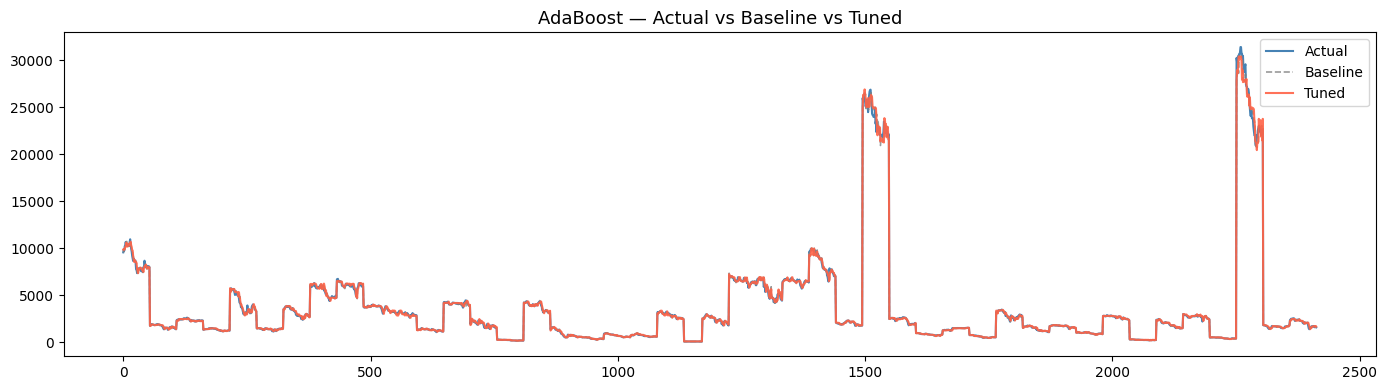

Waktu eksekusi AdaBoost (Baseline + Tuning): 20.61 menit

[SHAP Interpretation] AdaBoost


PermutationExplainer explainer: 2414it [17:05,  2.35it/s]


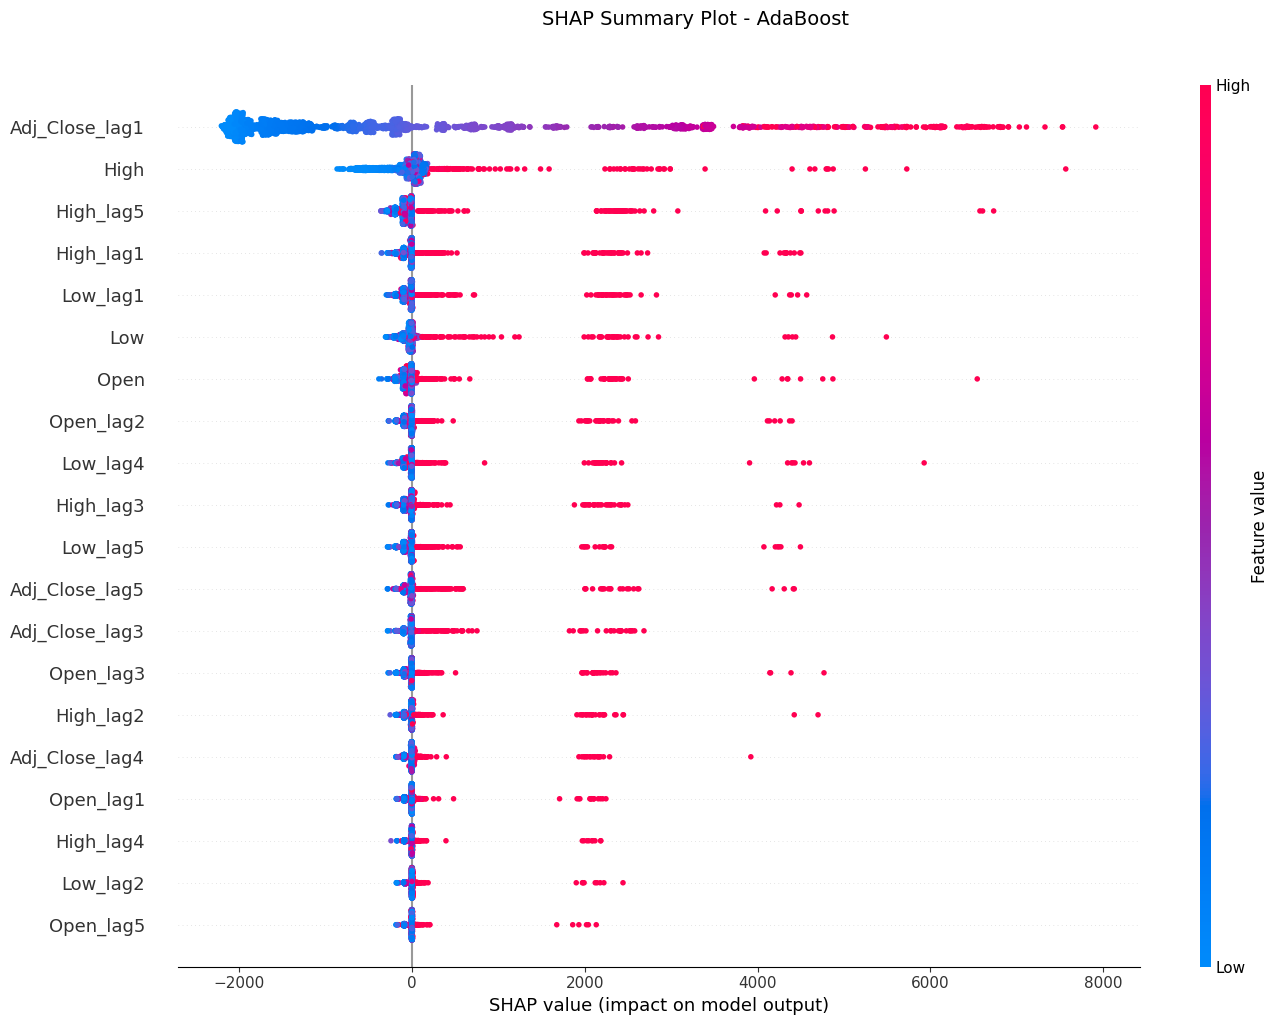

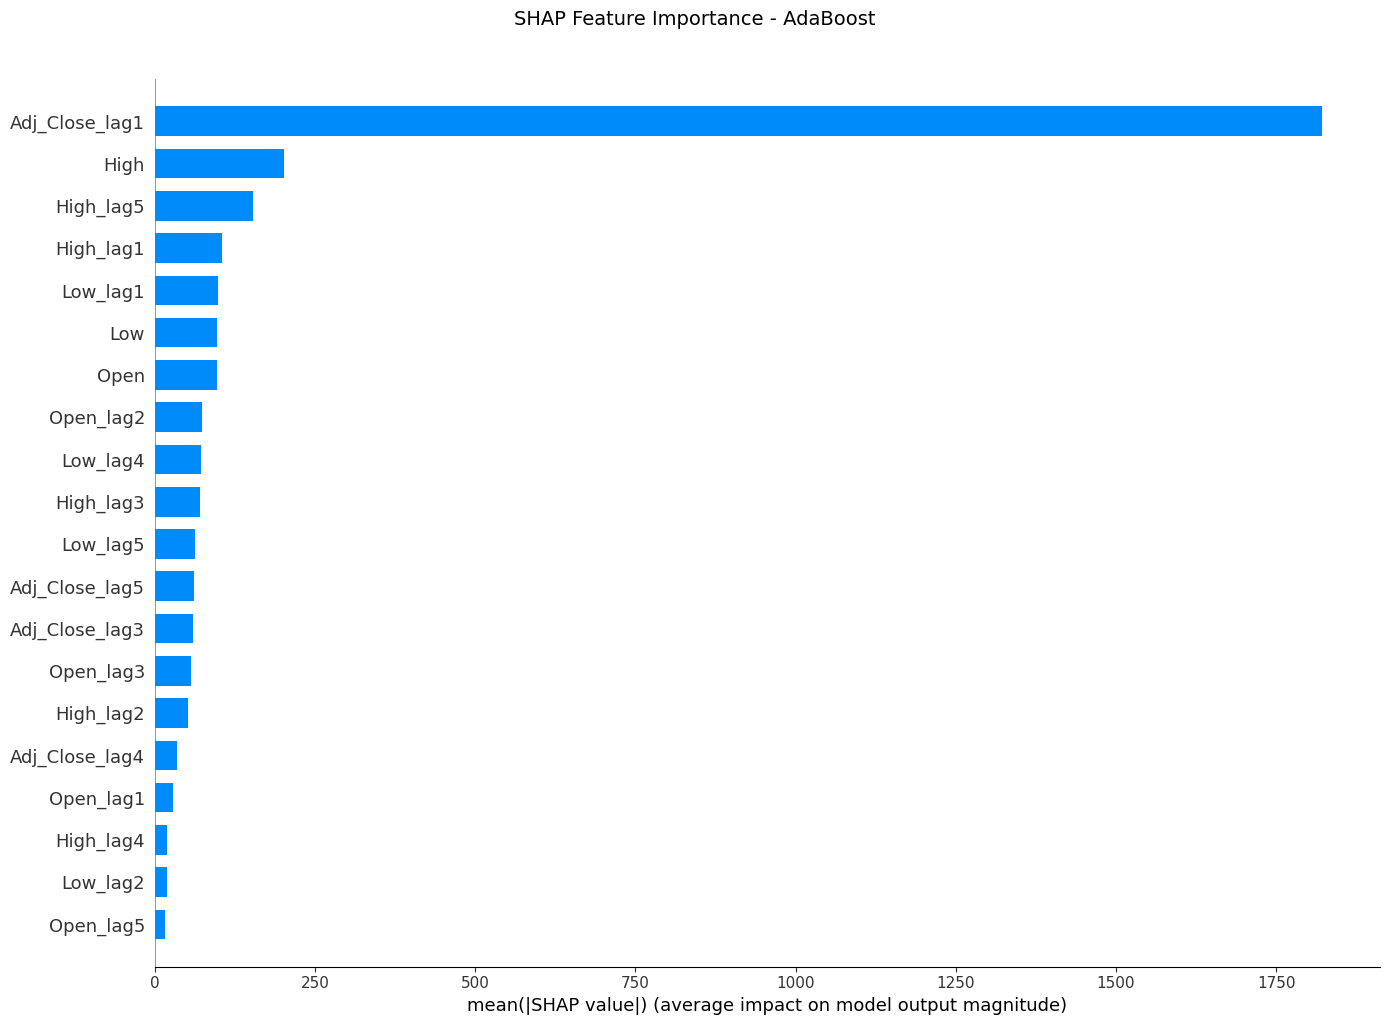

Ticker          : INDF
Observasi index : 1353


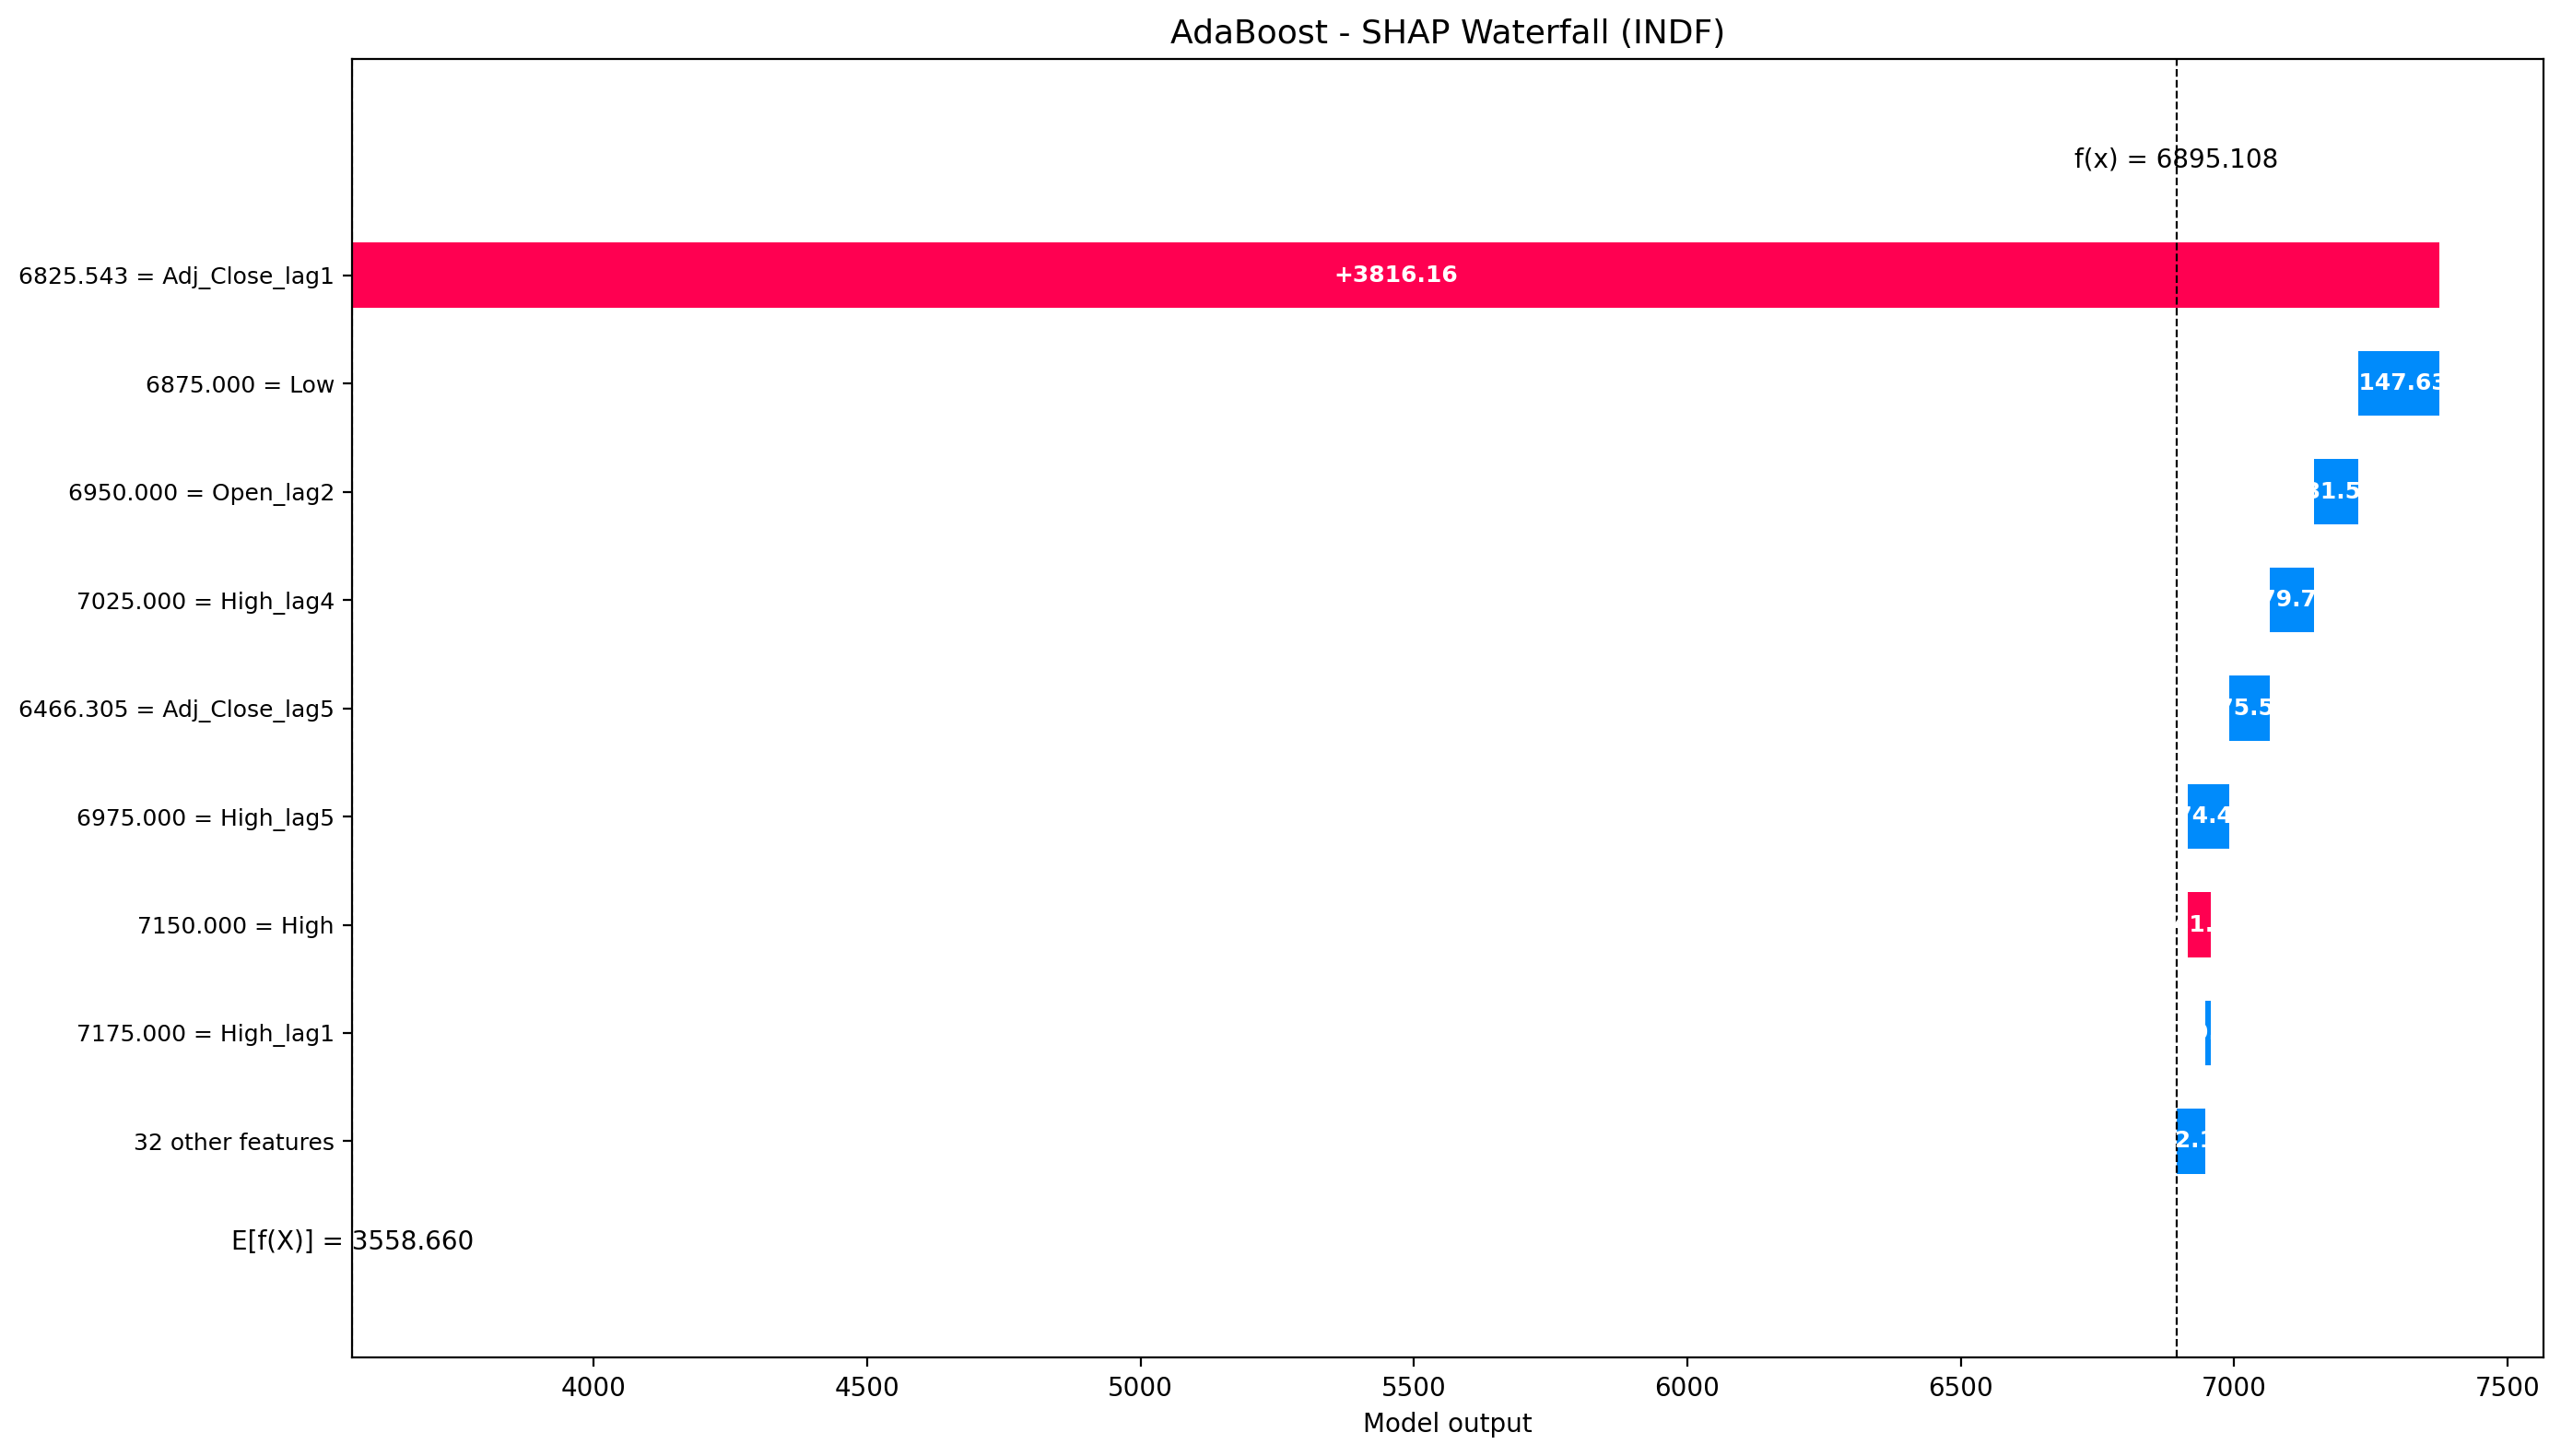


[Per-Ticker Evaluation] AdaBoost Tuned

Top 10 Ticker Terbaik (MAPE terkecil):
Ticker       RMSE        MAE     MAPE       R2
  PTBA  66.144651  45.650099 1.748418 0.793831
  ICBP 178.536299 124.371107 1.907623 0.593475
  INDF 154.653980 126.610149 1.980199 0.613186
  MAPI  47.900557  30.618977 2.195499 0.790824
  BMRI 125.091338  89.998111 2.196895 0.235829
  ADRO  64.271247  52.032227 2.202625 0.615177
  AKRA  36.653475  29.707649 2.291674 0.876234
  PGAS  59.090209  40.391543 2.525618 0.705372
  BBNI 131.709907  94.552048 2.654764 0.610373
  BBCA 230.976522 162.333566 2.771308 0.598807

Top 10 Ticker Terburuk (MAPE terbesar):
Ticker       RMSE        MAE      MAPE         R2
  ESSA  43.879838  35.107935  5.167446   0.812286
  HRTA 152.411676 119.805573  5.280082   0.783096
  INCO 371.429046 283.916138  5.353145   0.820116
  AMMN 281.527219 215.745282  5.480058   0.909073
  DEWA  29.621715  24.010886  6.365188   0.905910
  BUMI  17.625951  13.089388  7.270223   0.793336
  CUAN  92.4

In [ ]:
# ADABOOST
import time
from sklearn.tree import DecisionTreeRegressor

print("  ADABOOST")

start_time = time.time()
print("\n[Baseline]")
ada_base = AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=42)
ada_base.fit(X_train, y_train)
ada_pred_base = ada_base.predict(X_test)
ada_result_base = evaluate("AdaBoost Baseline", y_test, ada_pred_base)

print("\n[Tuned — GridSearchCV]")
ada_param_grid = {
    "learning_rate": [0.1, 0.5, 1.0],
    "n_estimators": [50, 100, 200],
    "estimator__max_depth": [6, 8]
}

ada_search = GridSearchCV(
    estimator=AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=42),
    param_grid=ada_param_grid,
    cv=tscv.split(X_train, y_train, groups=groups_train),
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1
)

ada_search.fit(X_train, y_train)
ada_best = ada_search.best_estimator_
ada_pred_tuned = ada_best.predict(X_test)
print("\nBest Parameters")
print(ada_search.best_params_)

print("\nBest CV MAPE (%)")
print(-ada_search.best_score_ * 100)

ada_result_tuned = evaluate("AdaBoost Tuned", y_test, ada_pred_tuned)

print_comparison_table("AdaBoost", ada_result_base, ada_result_tuned)

plot_comparison("AdaBoost", y_test, ada_pred_base, ada_pred_tuned)

end_time = time.time()

execution_time = end_time - start_time

print(f"Waktu eksekusi AdaBoost (Baseline + Tuning): "
      f"{execution_time / 60:.2f} menit")


shap_interpretation(
    model_name="AdaBoost",
    model=ada_best,
    X_train=X_train,
    X_test=X_test,
    ticker_labels=ticker_labels_test,
    waterfall_ticker="INDF",
    max_display=20
)

ada_per_ticker = evaluate_per_ticker(
    "AdaBoost Tuned",
    y_test,
    ada_pred_tuned,
    ticker_labels_test
)

XGBOOST

[Baseline]
RMSE  : 244.4882
MAE   : 113.8175
MAPE  : 4.11%
R2    : 0.9977

[Tuned — GridSearchCV]
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters
{'learning_rate': 0.03, 'max_depth': 8, 'n_estimators': 300}

Best CV MAPE (%)
3.502060074471373
RMSE  : 220.2935
MAE   : 102.8772
MAPE  : 3.46%
R2    : 0.9981

  XGBoost — Baseline vs Tuned
  Metrik         Baseline        Tuned       Diff
  ----------------------------------------------
  MAE            113.8175     102.8772 ↓ 10.9403 ✅
  RMSE           244.4882     220.2935 ↓ 24.1947 ✅
  MAPE             4.1056       3.4585 ↓  0.6472 ✅
  R2               0.9977       0.9981 ↑  0.0004 ✅


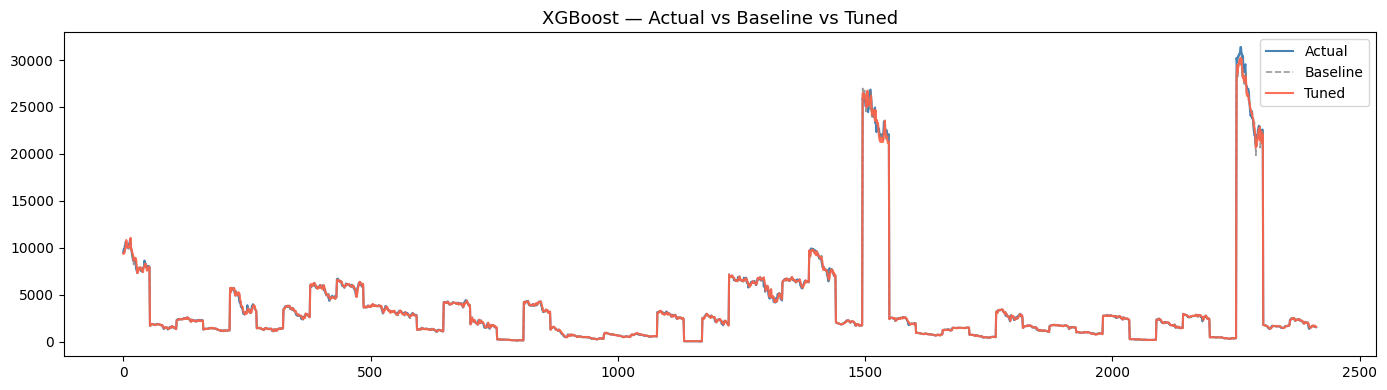

Waktu eksekusi XGBoost (Baseline + Tuning): 4.88 menit

[SHAP Interpretation] XGBoost


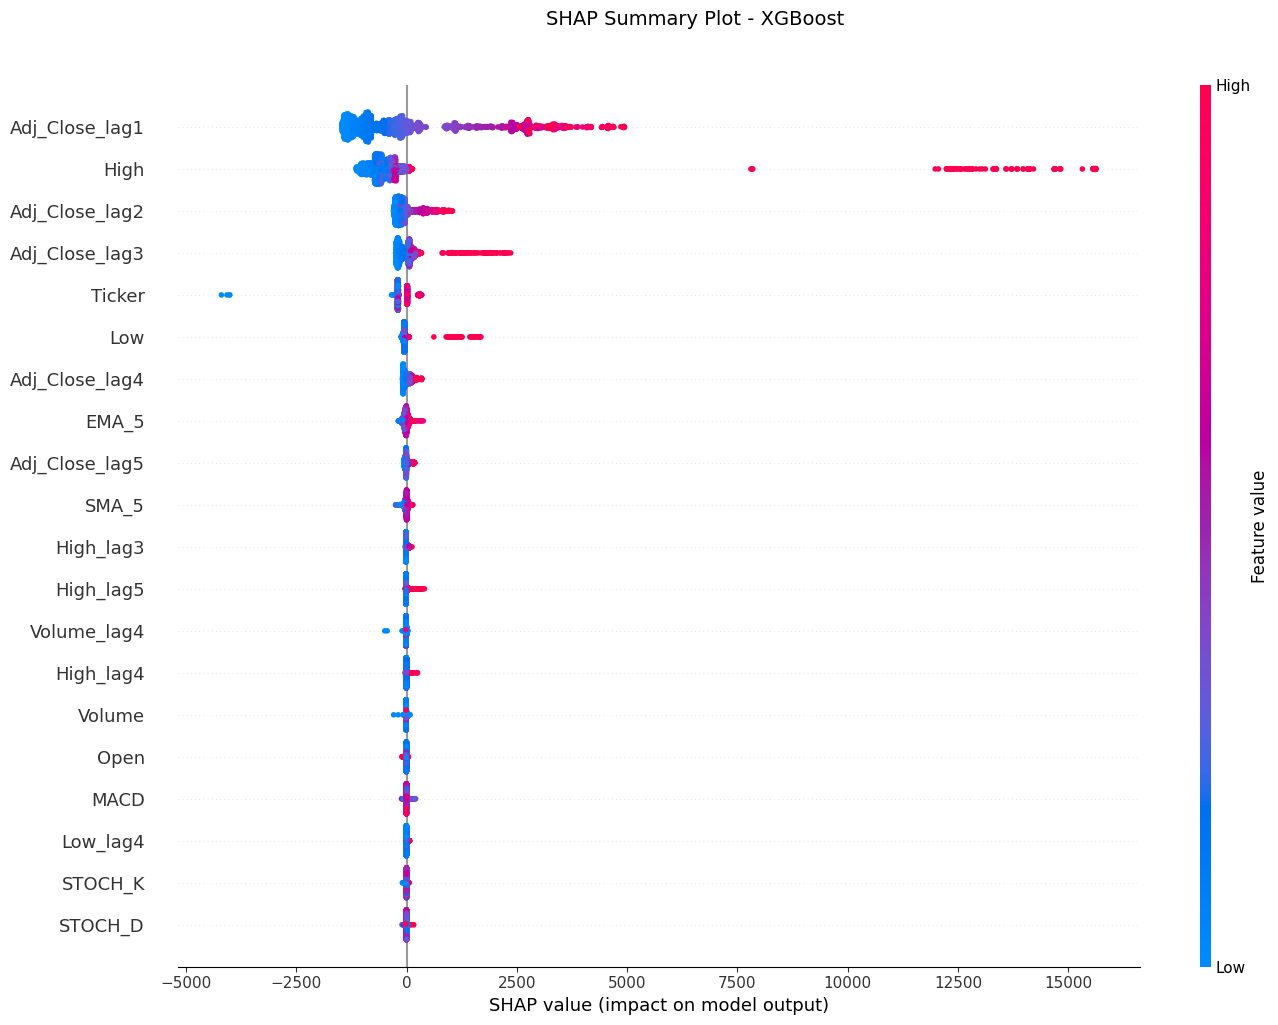

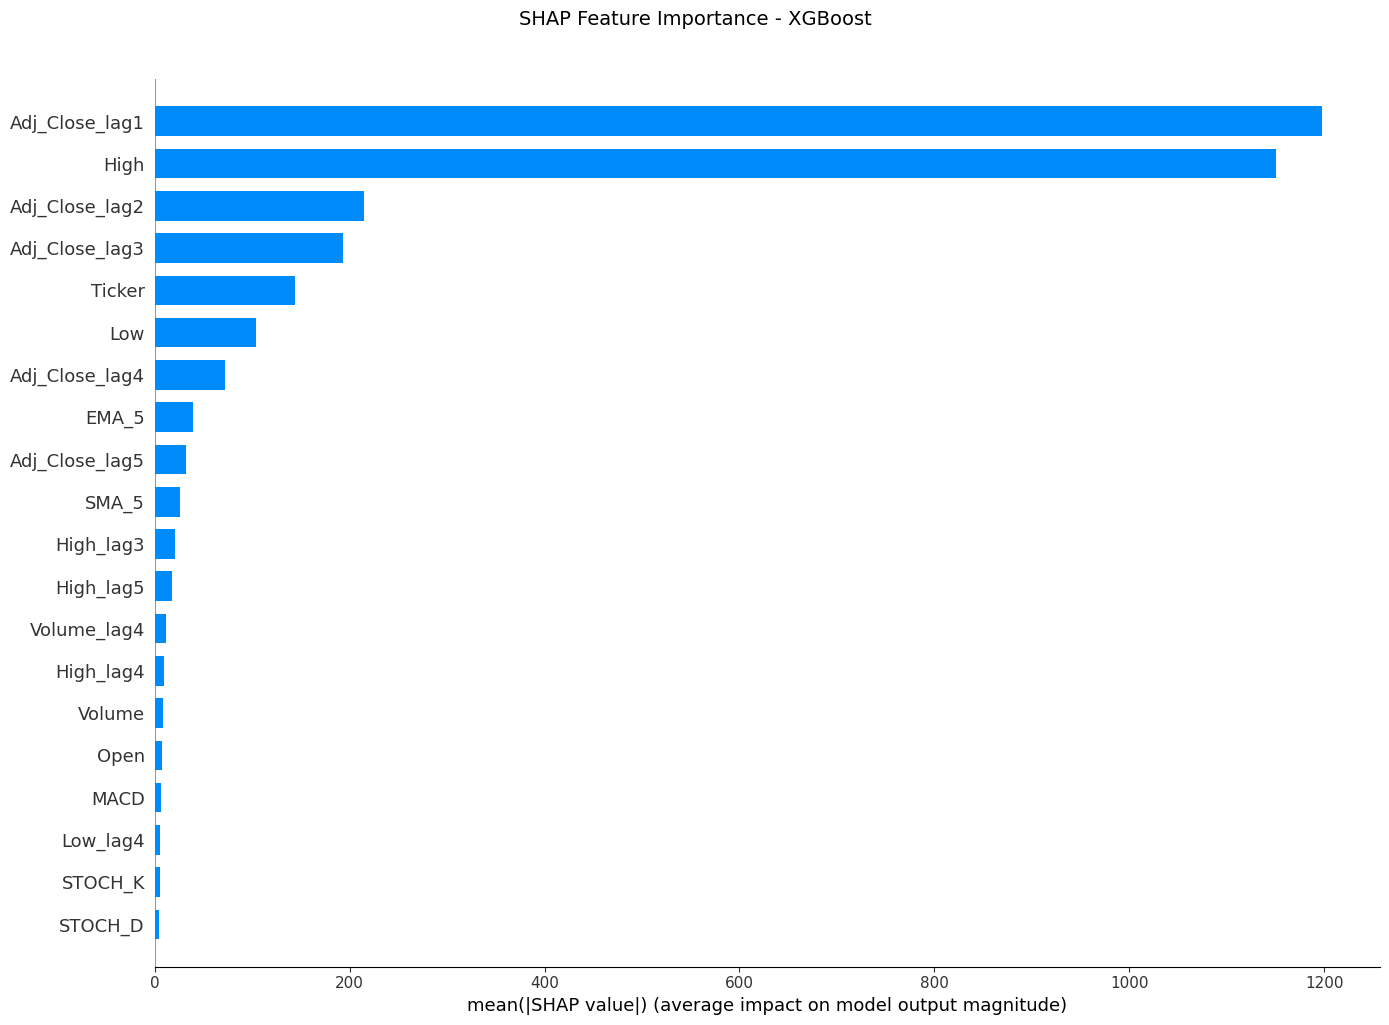

Ticker          : INDF
Observasi index : 1352


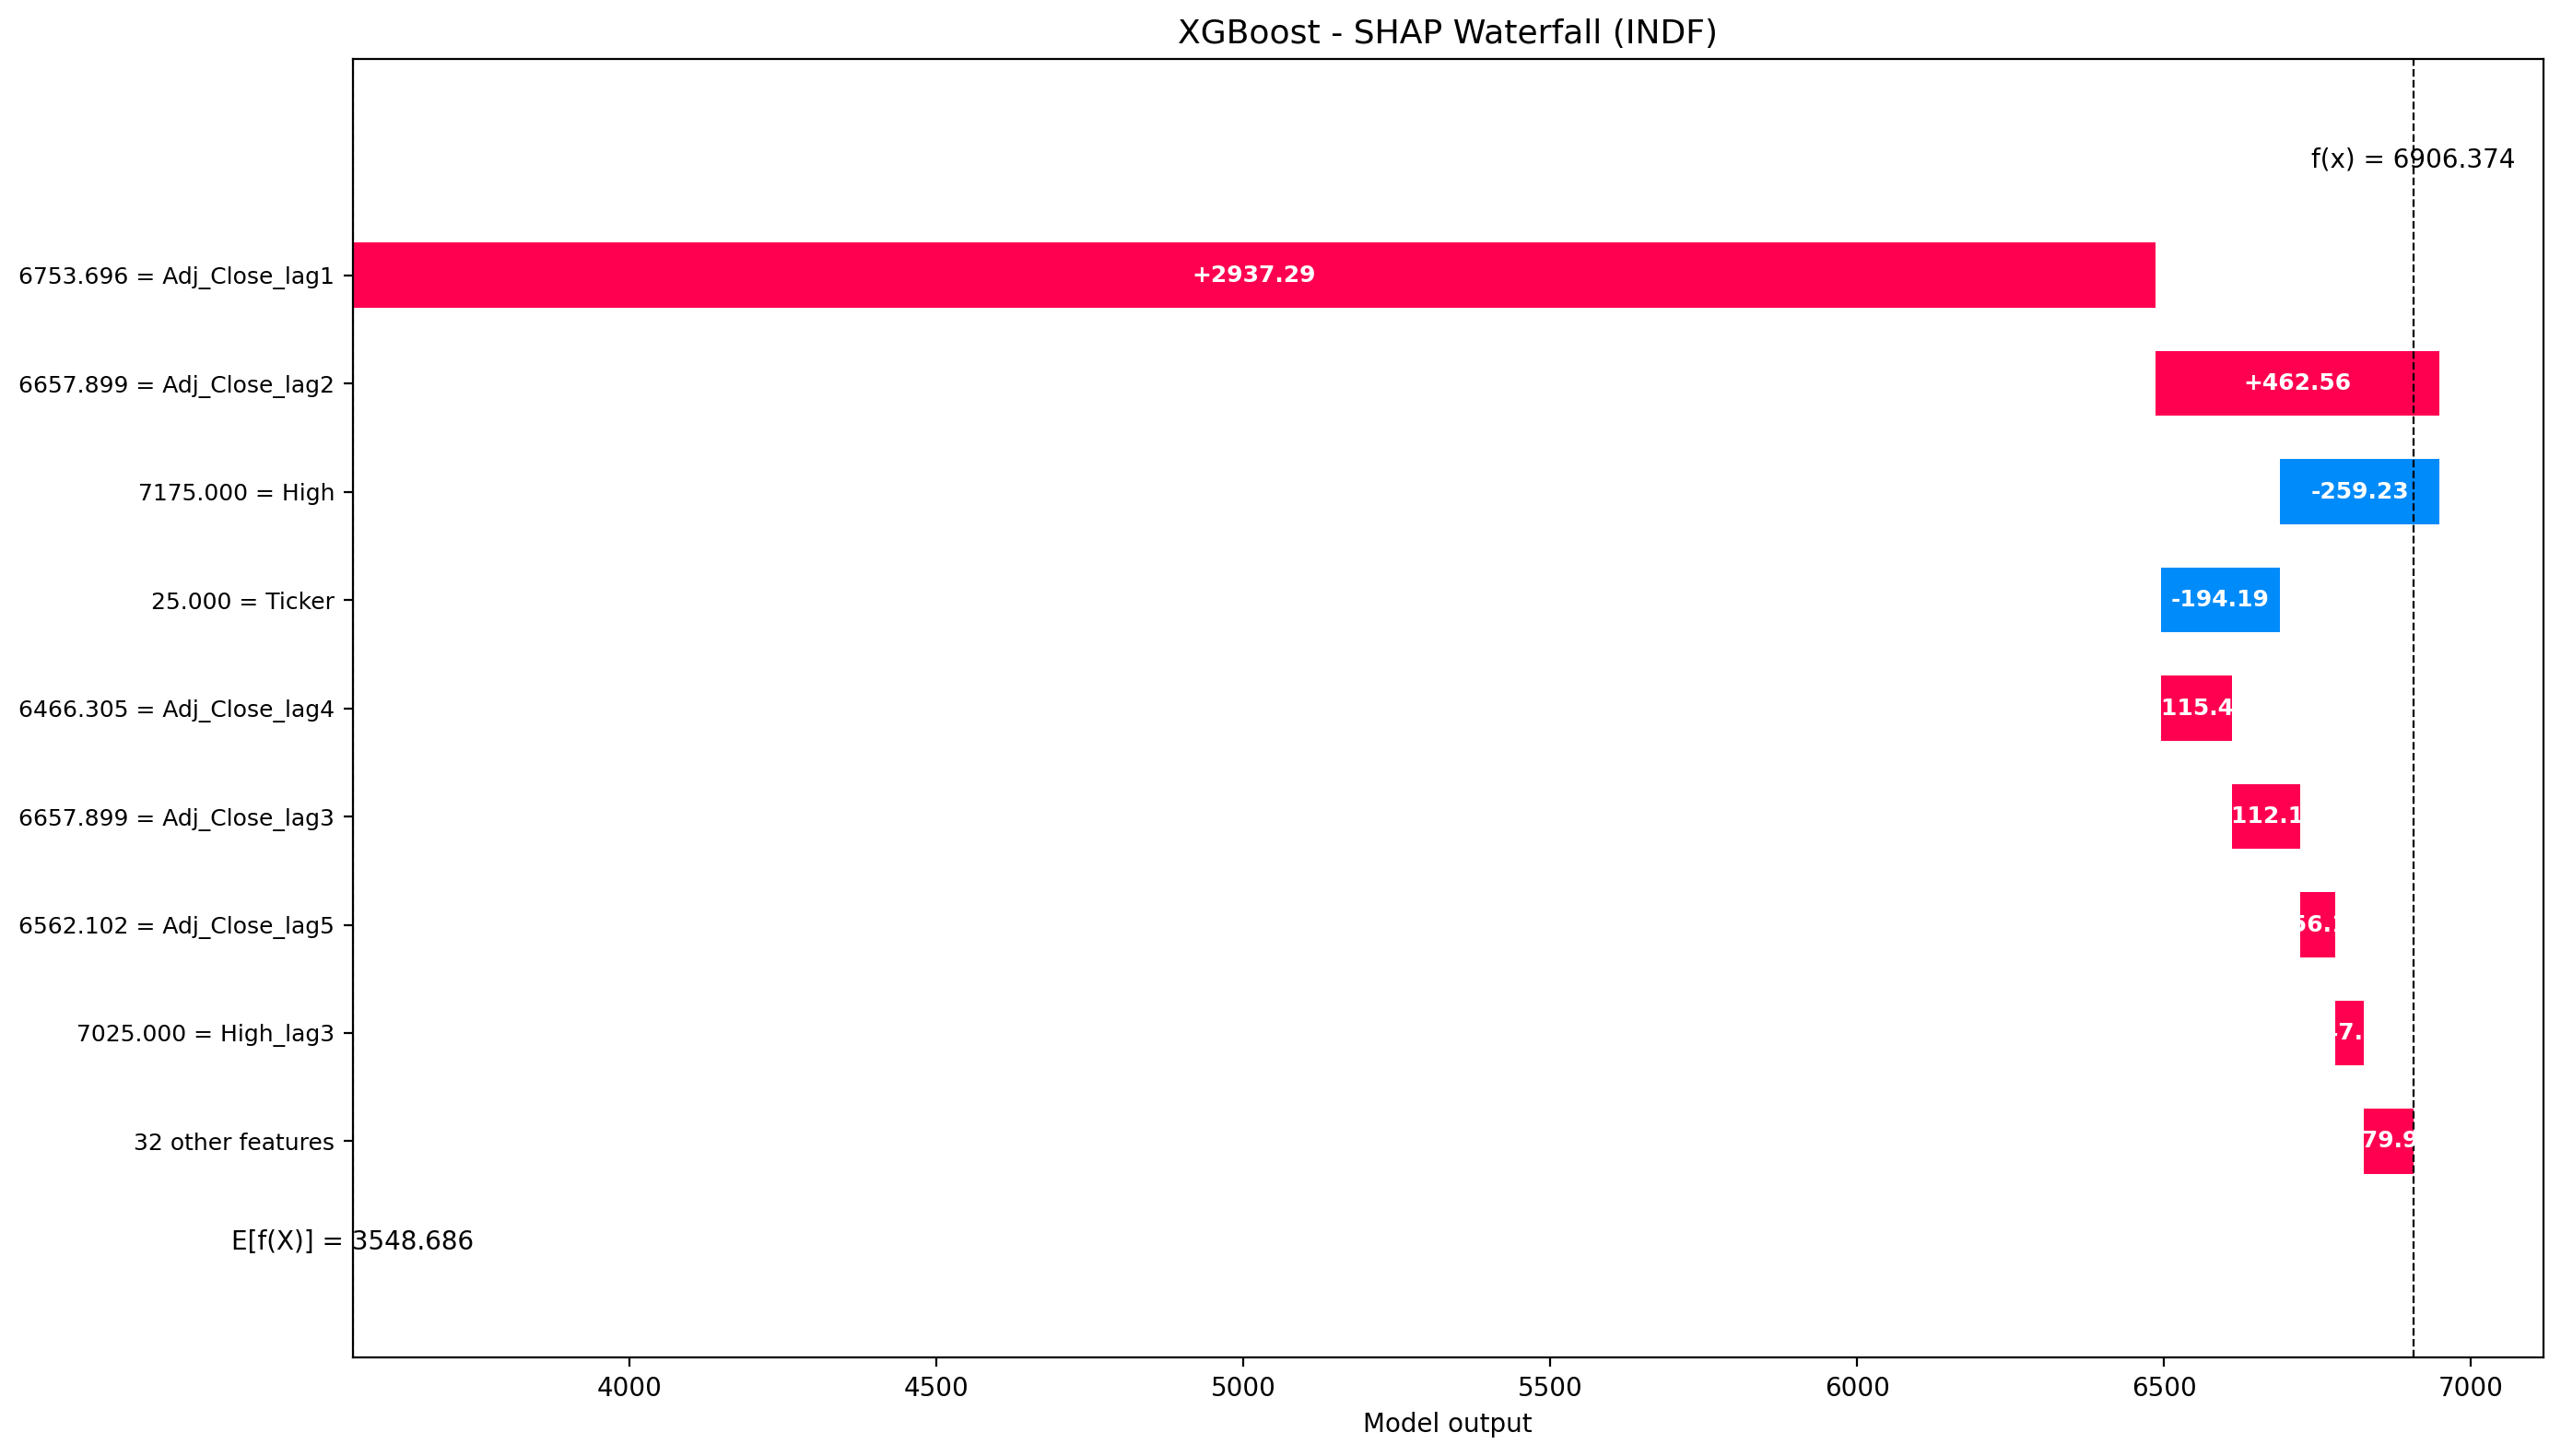


[Per-Ticker Evaluation] XGBoost Tuned

Top 10 Ticker Terbaik (MAPE terkecil):
Ticker       RMSE        MAE     MAPE       R2
  INDF 139.577364 104.580042 1.647970 0.684928
  ICBP 151.419266 108.934028 1.682659 0.707587
  PTBA  62.966386  44.311379 1.700349 0.813168
  AKRA  29.552481  23.982616 1.850798 0.919544
  MAPI  39.423084  26.266904 1.900594 0.858312
  BMRI 109.235328  79.968669 1.936320 0.417277
  ADRO  64.842162  47.220631 1.999298 0.608310
  PGAS  44.560242  32.776589 2.033345 0.832453
  ISAT  53.372418  40.265826 2.051520 0.895326
  BBCA 184.254787 130.216010 2.209223 0.744697

Top 10 Ticker Terburuk (MAPE terbesar):
Ticker       RMSE        MAE      MAPE         R2
  MDKA 142.324861 106.504851  3.881207   0.821109
  ESSA  39.760302  30.287567  4.433336   0.845878
  SCMA  13.579338  10.305225  4.465275   0.747343
  INCO 322.368296 237.713515  4.586939   0.864498
  DEWA  25.902040  20.229691  5.128291   0.928056
  BUMI  11.828819   9.820740  5.258583   0.906923
  AMMN 274.07

In [ ]:
# XGBOOST
import time
print("XGBOOST")

start_time = time.time()
print("\n[Baseline]")
xgb_base = XGBRegressor(random_state=42, verbosity=0)
xgb_base.fit(X_train, y_train)
xgb_pred_base = xgb_base.predict(X_test)
xgb_result_base = evaluate("XGBoost Baseline", y_test, xgb_pred_base)

print("\n[Tuned — GridSearchCV]")

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.15, 0.3],
    "max_depth": [6, 8]
}

cv_folds = list(tscv.split(X_train, y_train, groups=groups_train))

xgb_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42, verbosity=0),
    param_grid=xgb_param_grid,
    cv=cv_folds,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_
xgb_pred_tuned = xgb_best.predict(X_test)

print("\nBest Parameters")
print(xgb_search.best_params_)

print("\nBest CV MAPE (%)")
print(-xgb_search.best_score_ * 100)

xgb_result_tuned = evaluate("XGBoost Tuned", y_test, xgb_pred_tuned)

print_comparison_table("XGBoost", xgb_result_base, xgb_result_tuned)

plot_comparison("XGBoost", y_test, xgb_pred_base, xgb_pred_tuned)

end_time = time.time()

execution_time = end_time - start_time

print(f"Waktu eksekusi XGBoost (Baseline + Tuning): "
      f"{execution_time / 60:.2f} menit")


# SHAP (Waterfall khusus INDF)
shap_interpretation(
    model_name="XGBoost",
    model=xgb_best,
    X_train=X_train,
    X_test=X_test,
    ticker_labels=ticker_labels_test,
    waterfall_ticker="INDF",
    max_display=20
)

xgb_per_ticker = evaluate_per_ticker(
    "XGBoost Tuned",
    y_test,
    xgb_pred_tuned,
    ticker_labels_test
)

LIGHTGBM

[Baseline]
RMSE  : 219.6825
MAE   : 103.4157
MAPE  : 3.86%
R2    : 0.9982

[Tuned — GridSearchCV]
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters
{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300}

Best CV MAPE (%)
3.5726943459773395
RMSE  : 217.3828
MAE   : 101.9420
MAPE  : 3.63%
R2    : 0.9982

  LightGBM — Baseline vs Tuned
  Metrik         Baseline        Tuned       Diff
  ----------------------------------------------
  MAE            103.4157     101.9420 ↓  1.4737 ✅
  RMSE           219.6825     217.3828 ↓  2.2997 ✅
  MAPE             3.8593       3.6336 ↓  0.2257 ✅
  R2               0.9982       0.9982 ↑  0.0000 ✅


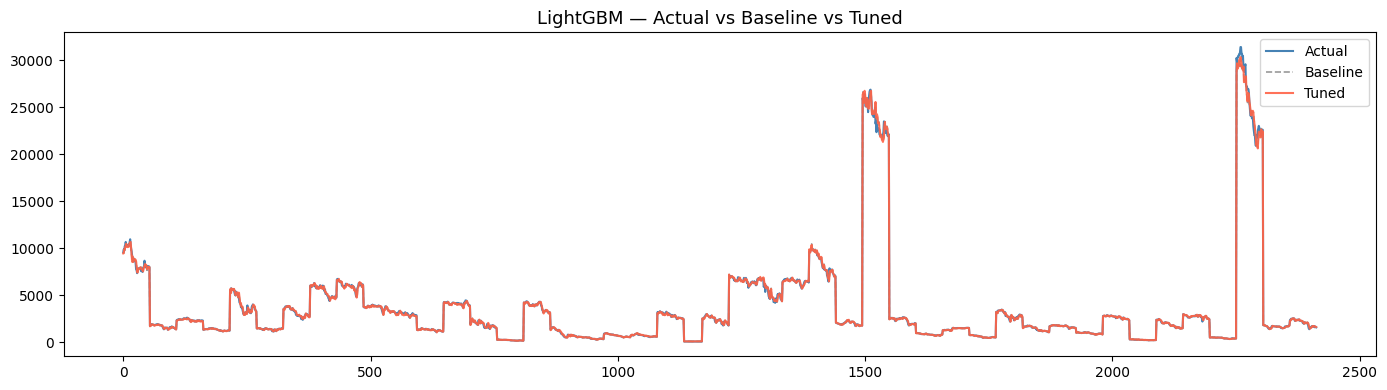

Waktu eksekusi LightGBM (Baseline + Tuning): 1.25 menit

[SHAP Interpretation] LightGBM


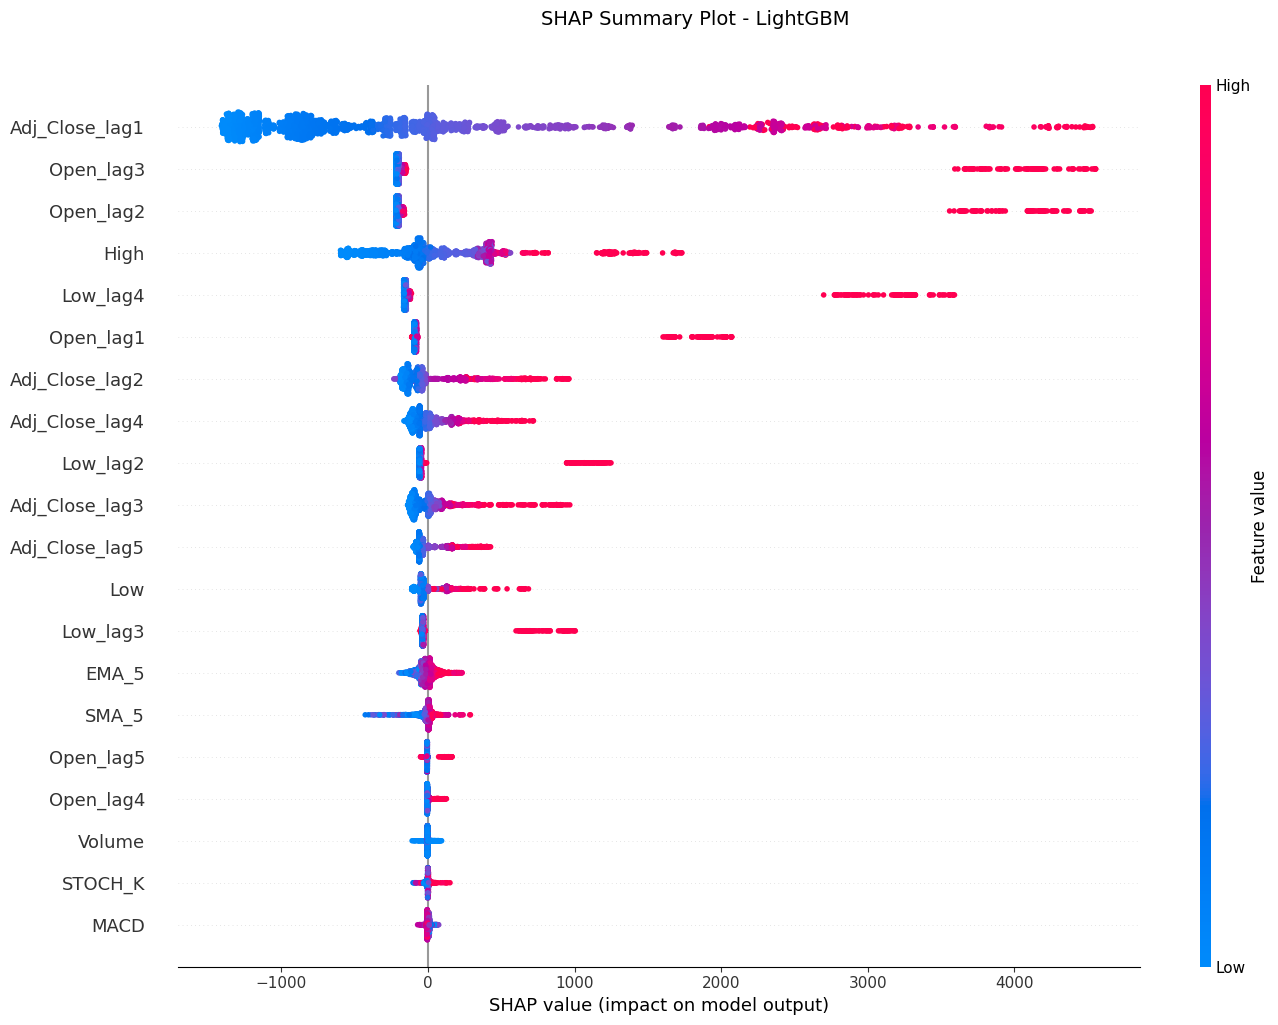

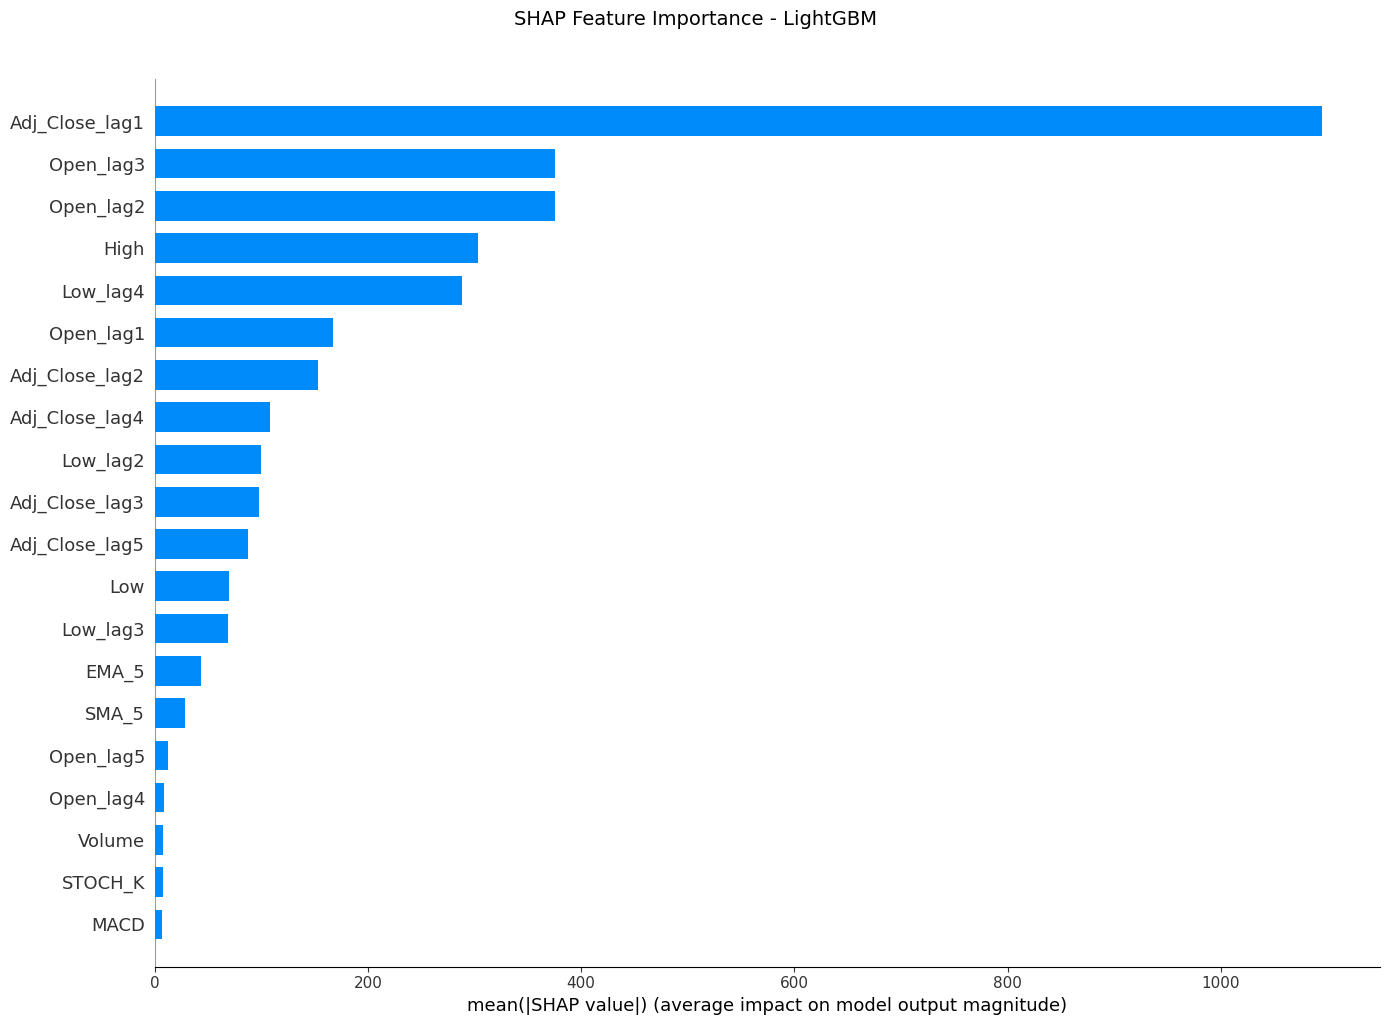

Ticker          : INDF
Observasi index : 1352


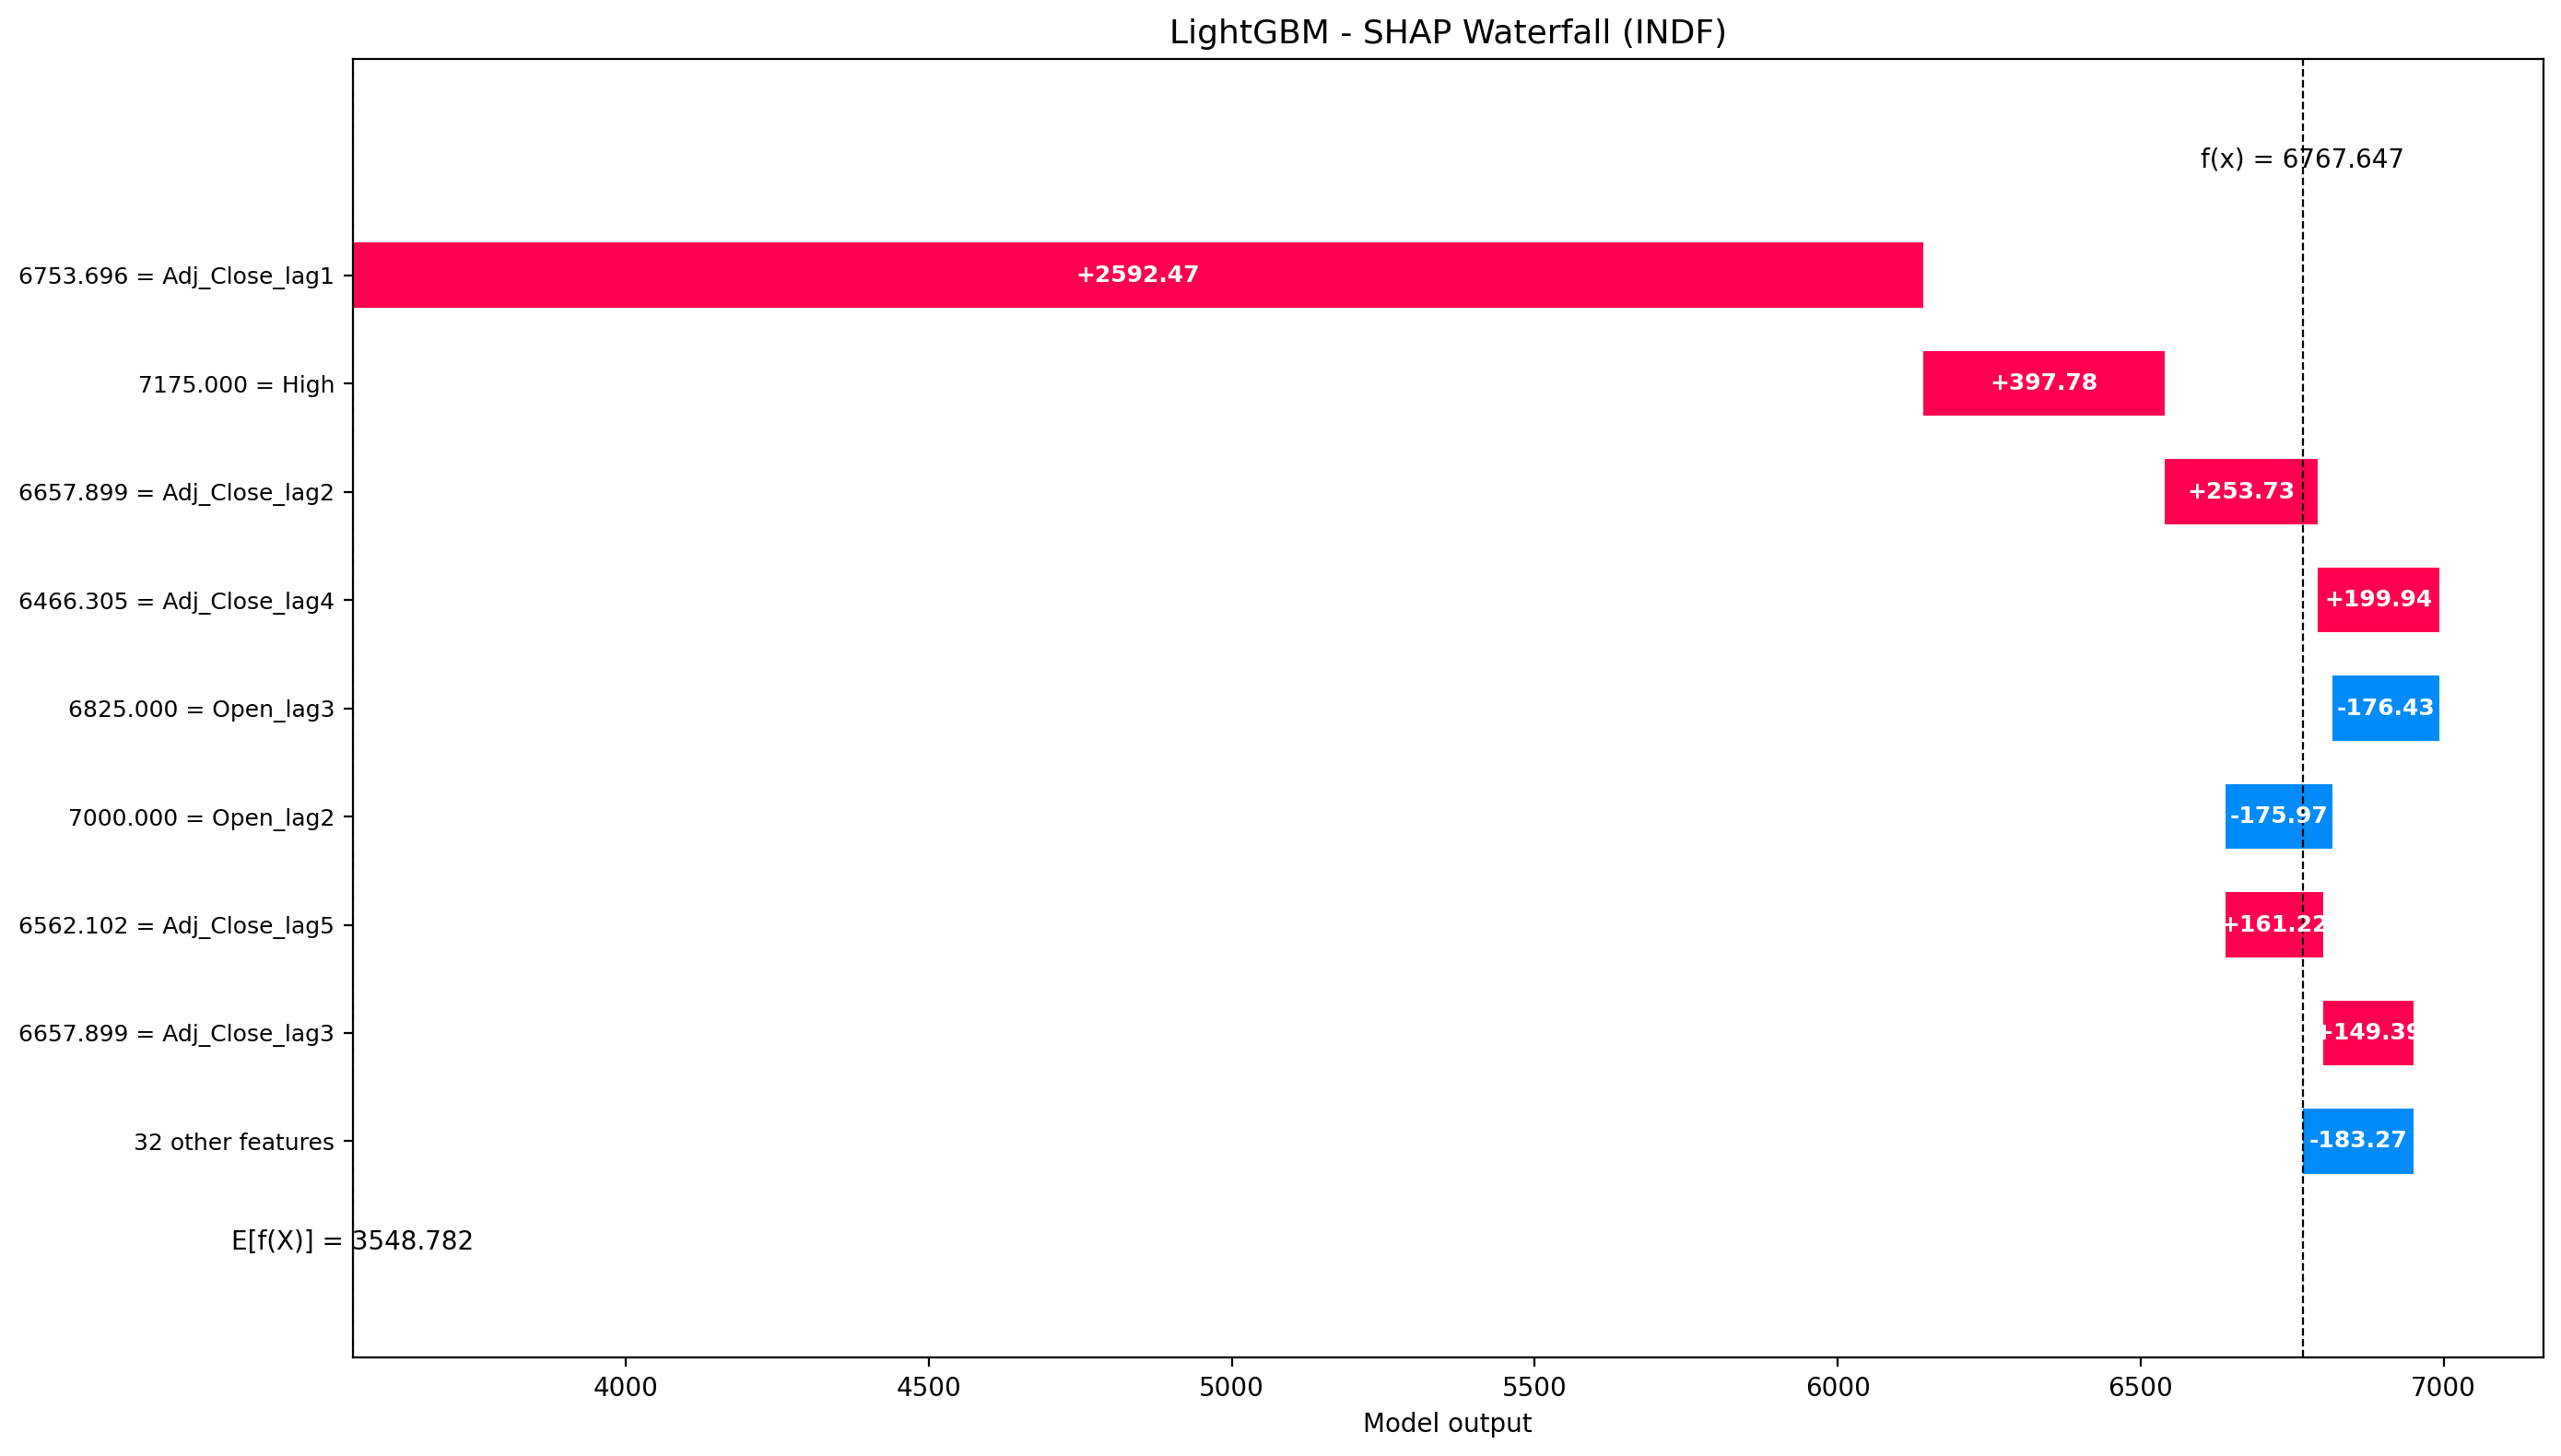


[Per-Ticker Evaluation] LightGBM Tuned

Top 10 Ticker Terbaik (MAPE terkecil):
Ticker       RMSE        MAE     MAPE       R2
  ICBP 147.225835 105.219305 1.614029 0.723559
  INDF 131.621307 103.878296 1.616530 0.719823
  PTBA  62.339965  46.777171 1.789412 0.816867
  MAPI  39.856307  26.878925 1.953369 0.855181
  BMRI 118.234078  80.848530 1.959366 0.317314
  PGAS  43.283381  31.683323 1.960592 0.841917
  AKRA  32.850505  27.654400 2.112146 0.900584
  CPIN 103.587008  80.042166 2.153302 0.931294
  UNVR  49.458921  34.762111 2.181850 0.775030
  BBCA 181.263967 131.926713 2.241771 0.752918

Top 10 Ticker Terburuk (MAPE terbesar):
Ticker       RMSE        MAE      MAPE         R2
  MDKA 153.593201 112.937380  4.138119   0.791661
  HRTA 131.355206  97.616517  4.297237   0.838889
  ESSA  41.596196  32.876441  4.849077   0.831316
  BUMI  11.577402   9.181854  5.035288   0.910838
  AMMN 261.929608 201.157148  5.078227   0.921291
  DEWA  26.041477  20.275269  5.279652   0.927280
  SCMA  16.9

In [ ]:
# LIGHTGBM
import time
print("LIGHTGBM")

start_time = time.time()
print("\n[Baseline]")
lgbm_base = LGBMRegressor(random_state=42, verbose=-1)
lgbm_base.fit(X_train, y_train)
lgbm_pred_base = lgbm_base.predict(X_test)
lgbm_result_base = evaluate("LightGBM Baseline", y_test, lgbm_pred_base)


print("\n[Tuned — GridSearchCV]")

lgbm_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 8]
}

cv_folds = list(tscv.split(X_train, y_train, groups=groups_train))

lgbm_search = GridSearchCV(
    estimator=LGBMRegressor(random_state=42, verbose=-1),
    param_grid=lgbm_param_grid,
    cv=cv_folds,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_train, y_train)
lgbm_best = lgbm_search.best_estimator_
lgbm_pred_tuned = lgbm_best.predict(X_test)

print("\nBest Parameters")
print(lgbm_search.best_params_)

print("\nBest CV MAPE (%)")
print(-lgbm_search.best_score_ * 100)

lgbm_result_tuned = evaluate("LightGBM Tuned", y_test, lgbm_pred_tuned)

print_comparison_table("LightGBM", lgbm_result_base, lgbm_result_tuned)

plot_comparison("LightGBM", y_test, lgbm_pred_base, lgbm_pred_tuned)

end_time = time.time()

execution_time = end_time - start_time

print(f"Waktu eksekusi LightGBM (Baseline + Tuning): "
      f"{execution_time / 60:.2f} menit")


shap_interpretation(
    model_name="LightGBM",
    model=lgbm_best,
    X_train=X_train,
    X_test=X_test,
    ticker_labels=ticker_labels_test,
    waterfall_ticker="INDF",
    max_display=20
)

lgbm_per_ticker = evaluate_per_ticker(
    "LightGBM Tuned",
    y_test,
    lgbm_pred_tuned,
    ticker_labels_test
)

  CATBOOST

[Baseline]
RMSE  : 249.0287
MAE   : 118.5661
MAPE  : 4.55%
R2    : 0.9976

[Tuned — GridSearchCV]
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters
{'iterations': 2000, 'learning_rate': 0.0658, 'max_depth': 6}

Best CV MAPE (%)
4.078620391685499
RMSE  : 249.4985
MAE   : 117.4245
MAPE  : 4.38%
R2    : 0.9976

  CatBoost — Baseline vs Tuned
  Metrik         Baseline        Tuned       Diff
  ----------------------------------------------
  MAE            118.5661     117.4245 ↓  1.1417 ✅
  RMSE           249.0287     249.4985 ↑  0.4698 ❌
  MAPE             4.5505       4.3776 ↓  0.1729 ✅
  R2               0.9976       0.9976 ↓  0.0000 ❌


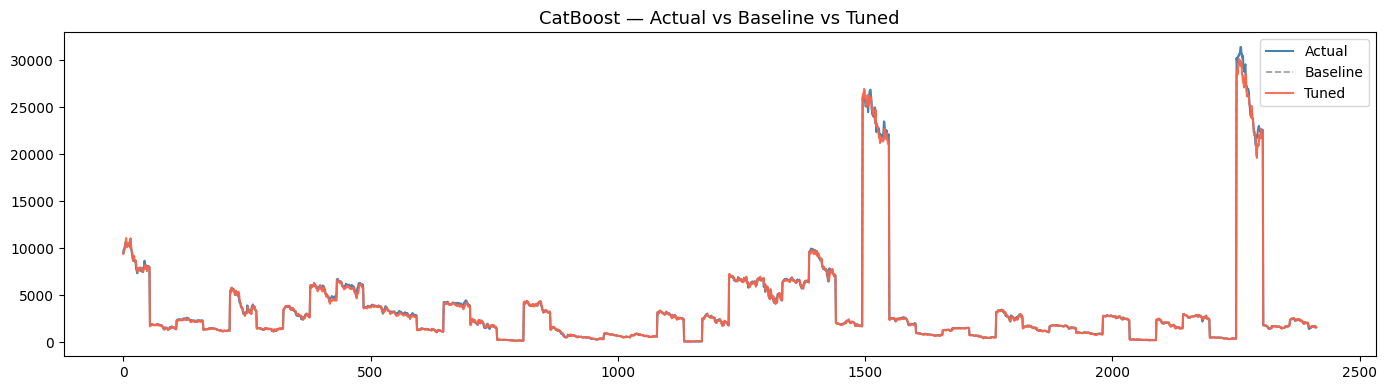

Waktu eksekusi CatBoost (Baseline + Tuning): 96.92 menit

[SHAP Interpretation] CatBoost


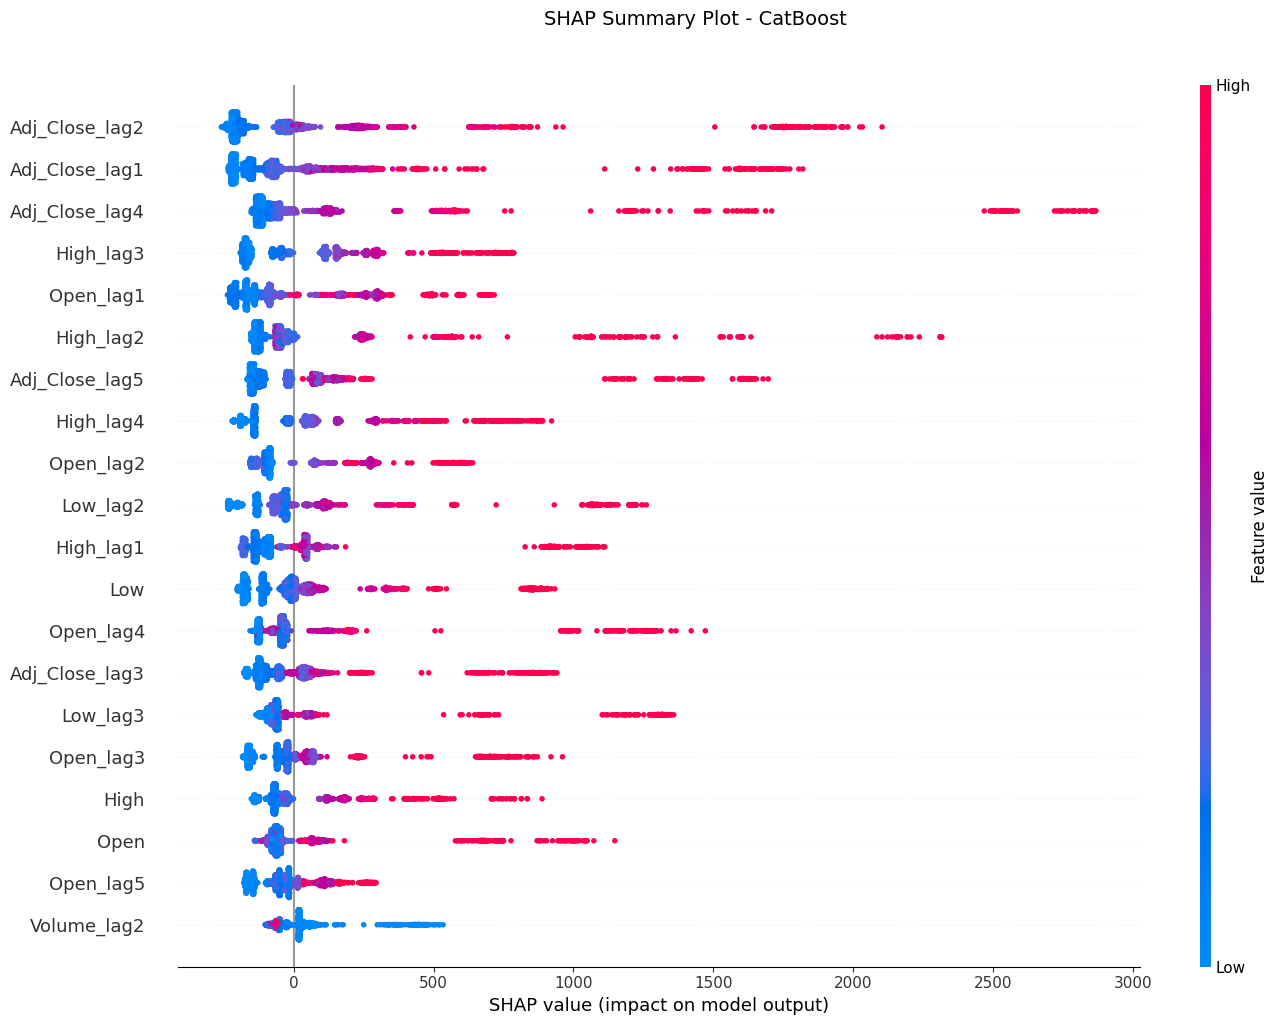

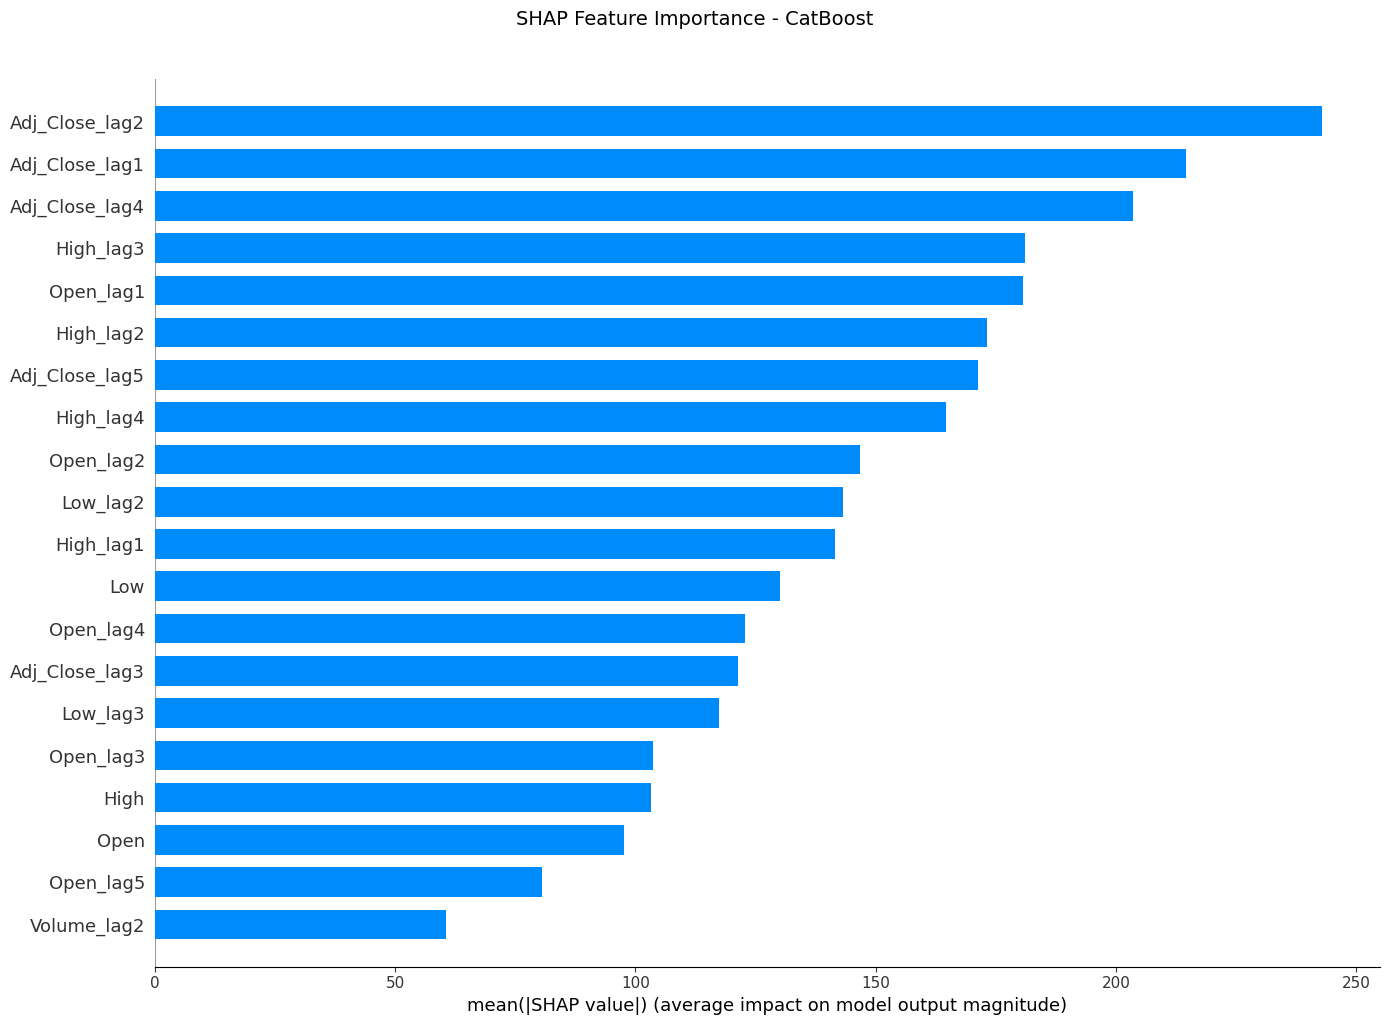

Ticker          : INDF
Observasi index : 1352


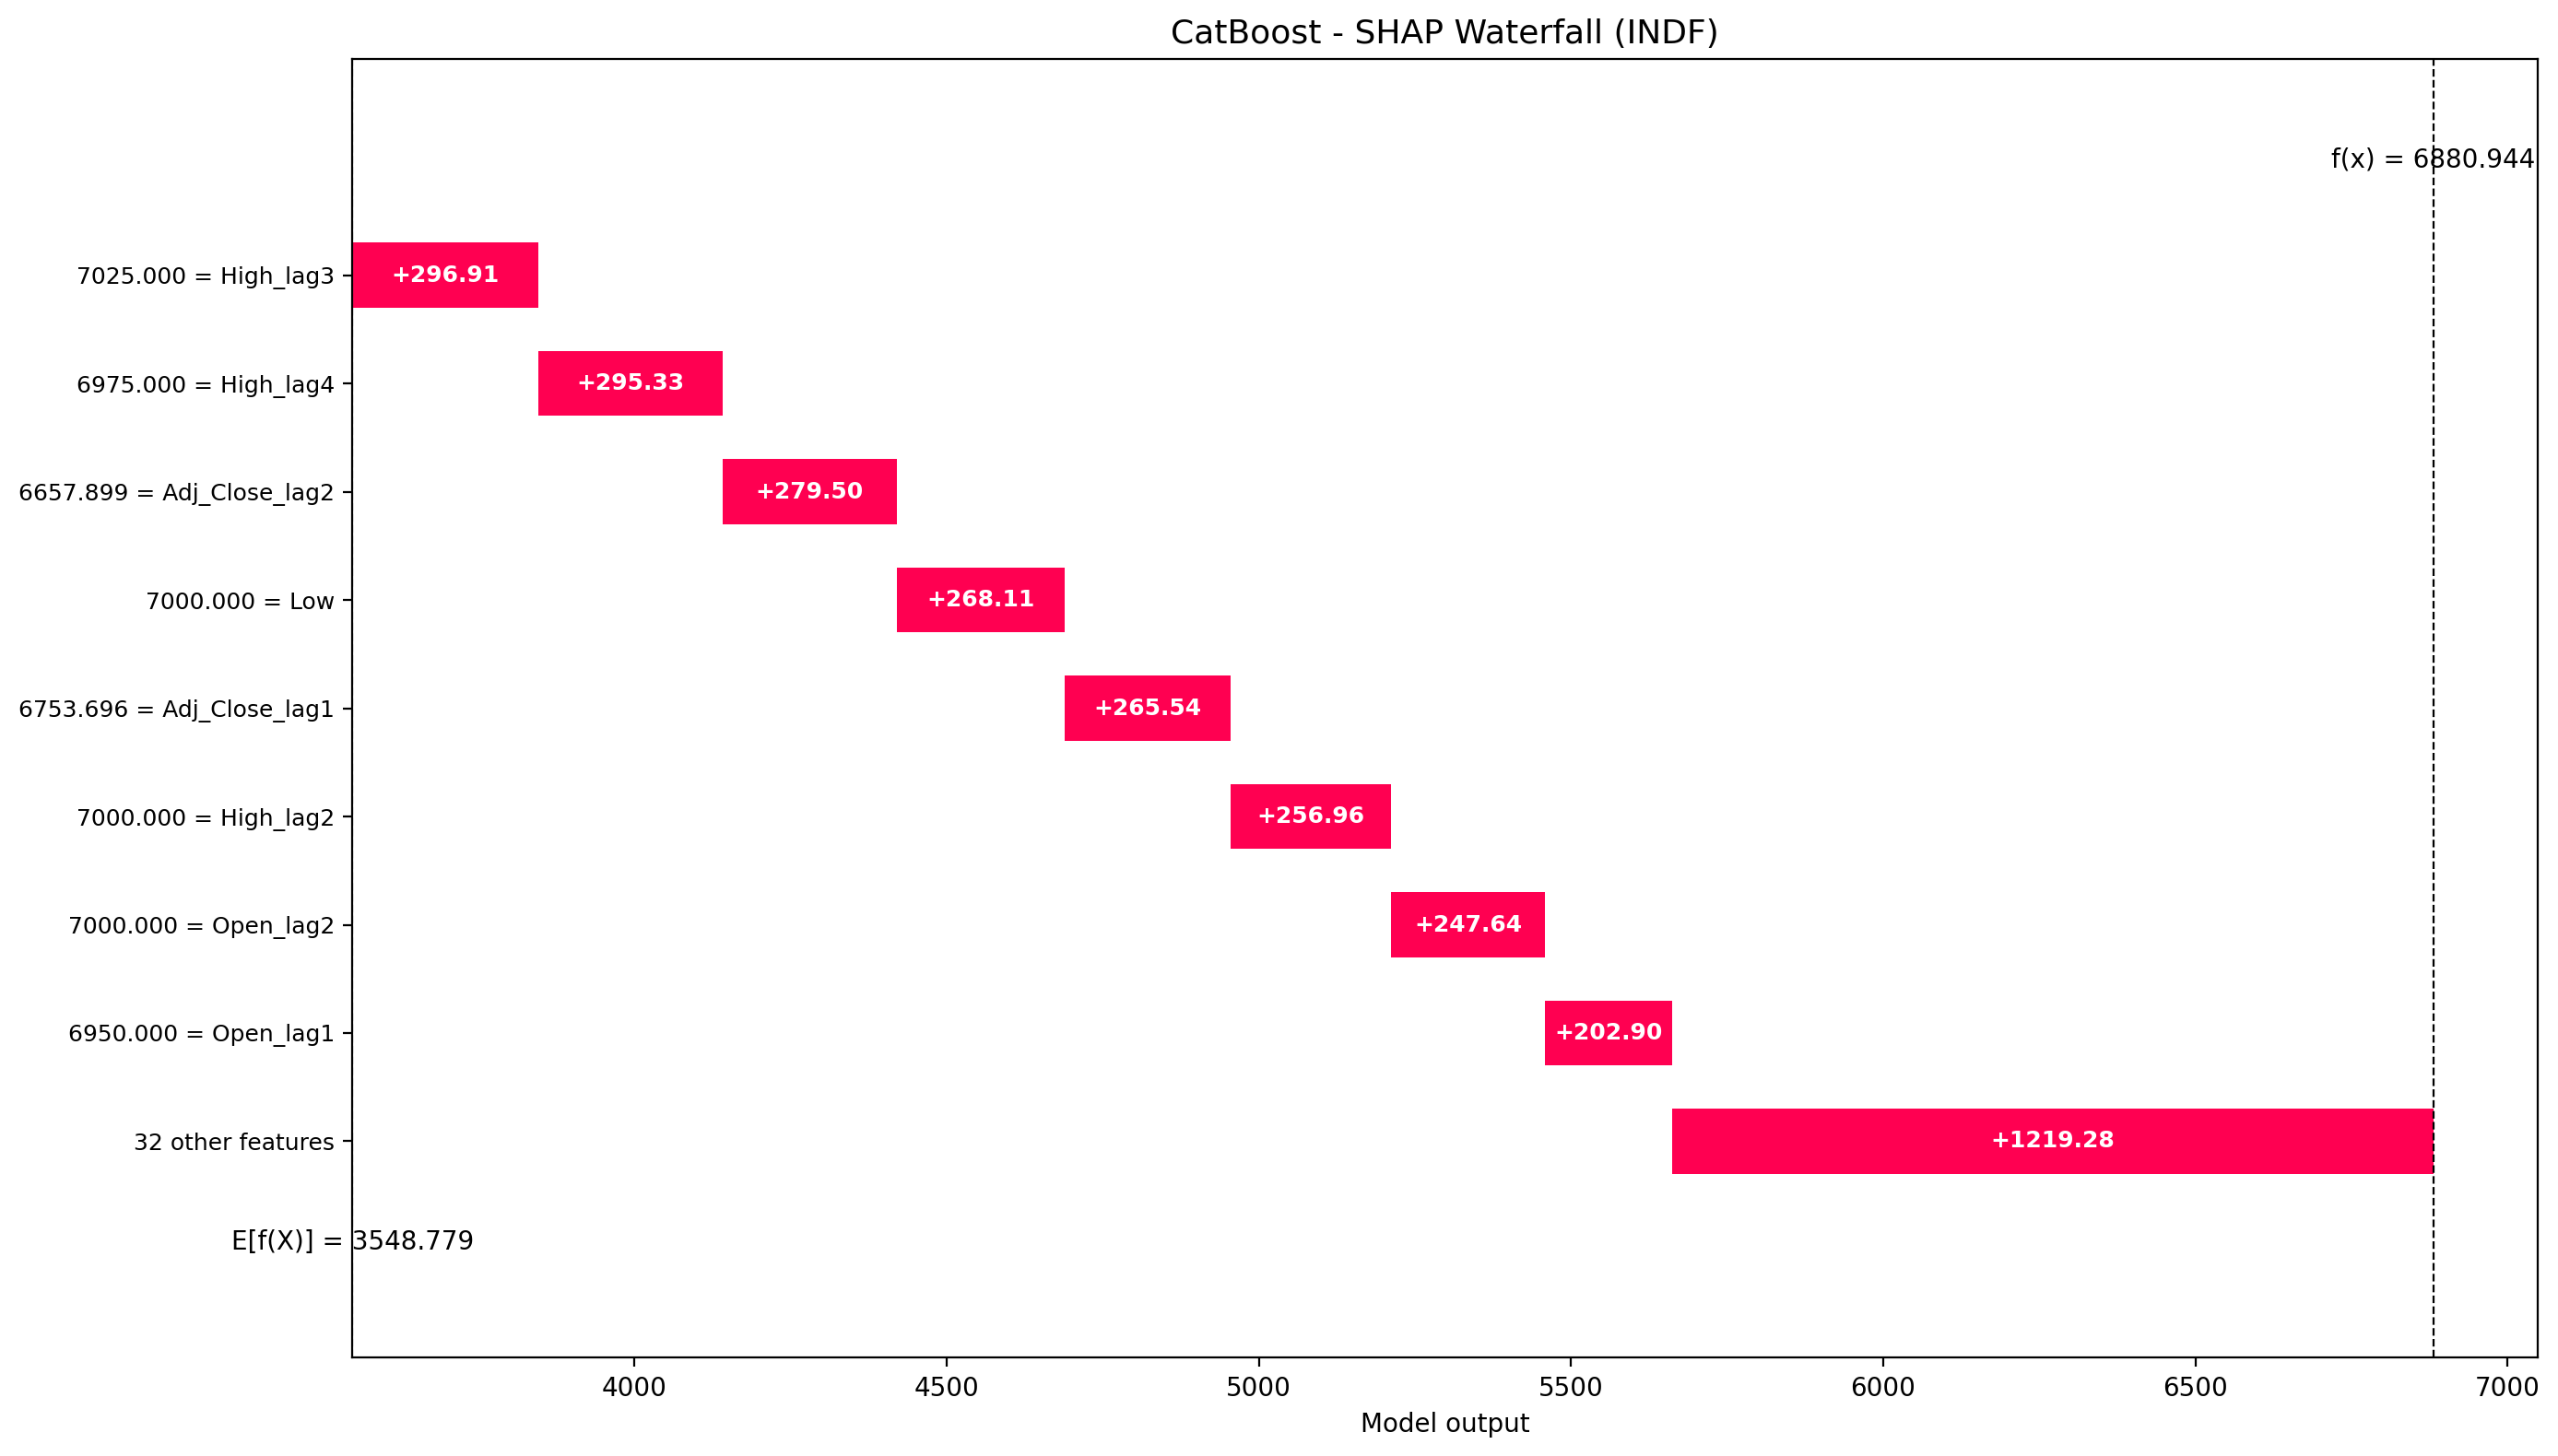


[Per-Ticker Evaluation] CatBoost Tuned

Top 10 Ticker Terbaik (MAPE terkecil):
Ticker       RMSE        MAE     MAPE       R2
  PTBA  59.304649  42.488434 1.626904 0.834266
  INDF 135.131020 109.226013 1.705244 0.704682
  ICBP 168.194504 128.886526 1.983501 0.639207
  AKRA  33.889252  26.103986 1.989344 0.894198
  MAPI  45.903461  32.657515 2.347625 0.807902
  TLKM  90.209392  63.291582 2.410463 0.633684
  ITMG 700.917283 586.984057 2.471029 0.818768
  PGAS  50.086253  40.025526 2.478578 0.788320
  INKP 264.368215 205.014967 2.492039 0.940239
  CPIN 122.579743  95.561260 2.537591 0.903790

Top 10 Ticker Terburuk (MAPE terbesar):
Ticker       RMSE        MAE      MAPE          R2
  TOWR  22.549207  17.524379  4.242749    0.849437
  INCO 316.853189 225.022993  4.279633    0.869094
  AMMN 257.786966 194.333140  4.884841    0.923761
  BBRI 181.070657 159.464115  5.246164   -0.343551
  DEWA  28.637248  22.994563  5.777663    0.912060
  BUMI  14.234713  10.578664  5.852735    0.865210
  BRP

In [ ]:
import time
print("  CATBOOST")

start_time = time.time()
cat_feature_names = ["Ticker"]

cat_features_idx = [
    X_train.columns.get_loc(c)
    for c in cat_feature_names
]

print("\n[Baseline]")

cat_base = CatBoostRegressor(
    random_state=42,
    verbose=0,
    cat_features=cat_features_idx
)

cat_base.fit(
    X_train,
    y_train
)

cat_pred_base = cat_base.predict(X_test)

cat_result_base = evaluate(
    "CatBoost Baseline",
    y_test,
    cat_pred_base
)


print("\n[Tuned — GridSearchCV]")

cat_param_grid = {
    "learning_rate": [0.0066, 0.0329, 0.0658],
    "iterations": [1000, 2000, 3000],
    "max_depth": [6, 8]
}

cv_folds = list(
    tscv.split(
        X_train,
        y_train,
        groups=groups_train
    )
)

cat_search = GridSearchCV(
    estimator=CatBoostRegressor(
        random_state=42,
        verbose=0
    ),
    param_grid=cat_param_grid,
    cv=cv_folds,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1
)

cat_search.fit(
    X_train,
    y_train,
    cat_features=cat_features_idx
)

cat_best = cat_search.best_estimator_

cat_pred_tuned = cat_best.predict(X_test)

print("\nBest Parameters")
print(cat_search.best_params_)

print("\nBest CV MAPE (%)")
print(-cat_search.best_score_ * 100)


cat_result_tuned = evaluate(
    "CatBoost Tuned",
    y_test,
    cat_pred_tuned
)

print_comparison_table(
    "CatBoost",
    cat_result_base,
    cat_result_tuned
)

plot_comparison(
    "CatBoost",
    y_test,
    cat_pred_base,
    cat_pred_tuned
)

end_time = time.time()

execution_time = end_time - start_time

print(f"Waktu eksekusi CatBoost (Baseline + Tuning): "
      f"{execution_time / 60:.2f} menit")

shap_interpretation(
    model_name="CatBoost",
    model=cat_best,
    X_train=X_train,
    X_test=X_test,
    ticker_labels=ticker_labels_test,
    waterfall_ticker="INDF",
    max_display=20
)

cat_per_ticker = evaluate_per_ticker(
    "CatBoost Tuned",
    y_test,
    cat_pred_tuned,
    ticker_labels_test
)

In [ ]:
from catboost import CatBoostRegressor

cat_default = CatBoostRegressor(random_state=42, verbose=0)
cat_default.fit(X_train, y_train)

print(cat_default.get_all_params())

{'nan_mode': 'Min', 'eval_metric': 'RMSE', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'rsm': 1, 'boost_from_average': True, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'random_seed': 42, 'depth': 6, 'posterior_sampling': False, 'border_count': 254, 'classes_count': 0, 'auto_class_weights': 'None', 'sparse_features_conflict_fraction': 0, 'leaf_estimation_backtracking': 'AnyImprovement', 'best_model_min_trees': 1, 'model_shrink_rate': 0, 'min_data_in_leaf': 1, 'loss_function': 'RMSE', 'learning_rate': 0.06576500087976456, 

In [ ]:
# XGBoost
xgb_default = XGBRegressor(random_state=42, verbosity=0)
xgb_default.fit(X_train, y_train)
print("XGBoost params:", xgb_default.get_params())

# LightGBM
from lightgbm import LGBMRegressor
lgb_default = LGBMRegressor(random_state=42)
lgb_default.fit(X_train, y_train)
print("LightGBM params:", lgb_default.get_params())

# AdaBoost
from sklearn.ensemble import AdaBoostRegressor
ada_default = AdaBoostRegressor(random_state=42)
ada_default.fit(X_train, y_train)
print("AdaBoost params:", ada_default.get_params())

XGBoost params: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': 0}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the ov

In [ ]:
xgb_default = XGBRegressor(random_state=42, verbosity=0)
xgb_default.fit(X_train, y_train)

# Cara paling akurat: cek dari booster config
import json
config = json.loads(xgb_default.get_booster().save_config())
print("learning_rate (eta):", config['learner']['gradient_booster']['tree_train_param']['eta'])
print("max_depth:", config['learner']['gradient_booster']['tree_train_param']['max_depth'])

learning_rate (eta): 0.300000012
max_depth: 6


In [ ]:
xgb_default = XGBRegressor(random_state=42, verbosity=0)
xgb_default.fit(X_train, y_train)

# Cek learning_rate dan max_depth dari booster config
import json
config = json.loads(xgb_default.get_booster().save_config())
print("learning_rate (eta):", config['learner']['gradient_booster']['tree_train_param']['eta'])
print("max_depth:", config['learner']['gradient_booster']['tree_train_param']['max_depth'])

# Cek n_estimators (jumlah boosting rounds)
print("n_estimators:", xgb_default.get_num_boosting_rounds())

learning_rate (eta): 0.300000012
max_depth: 6
n_estimators: 100
